# 1 B Reel Değerli Evrişimli Yapay Sinir Ağları (1B-RD EYSA) ile DNA-KODON- AMİNO ASİT Dizi Sınıflandırma ve 1B-KD EYSA Sonuçları ile karşılaştırma
#### Açıklama: 
- Daha önce; İnsan vucuduna ait ve yaklaşık 500 ve üzeri protein çeşitliliği içeren Kinaz ve GPCR protein aileleri için UniProt uzantılı erişm (Acces) noları ile oluşturulan havuzdan herbir protein ailesi için basit rastgele örnekleme yöntemiyle (Simple Random Sampling) Train için 200 er örnek ve test için 100 er örnek seçilmiş; UniProt VE NCBI gen bankasından uzantılı erişm (Acces) numaralarıyla CDS-DNA, KODON ve AMİNOASİT dizi formları fasta olarak indirilmiş; indirilen herbir dizi formuna ait örnekler, karşılaştırma amaçlı literatürde bilinen reel değerli Tam sayılı kodlama yöntemleri kullanılarak tam sayılara kodlanmış ve her bir dizi formu için .NPZ dosyasına train (Train toplam: 400) ve test (Test toplam: 200) olarak kaydedilmiştir.
- Bu bölümde ise; Tam sayı değerlerine dönüştürülmüş Kinaz ve GPCR proteinlerine ait DNA, KODON ve AMİNO ASİT dizileri 1 Boyutlu REEL Değerli Evrişimli Yapay Sinir Ağları (1B RD EYSA) kullanılarak sınıflandırılmaktadır. 400 train örnek üzerinde 10-fold cross validation ile model değerlendirilir. Ardından aynı veri havuzu kullanılarak model yeniden eğitilir ve .npz dosyasındaki veri setinin 2. sayfadaki 200 bağımsız örnek üzerinde nihai test yapılmaktadır. Sonuçlar grafiklerle görselleştirilmekte ve bir dosyaya karşılaştırma için raporlanmaktadır. 


### Çalışma Adımları:
#### 1. Adım: 1B RD EYSA ile DNA dizisi sınıflandırma
- Tam sayı değerlerine dönüştürülmüş DNA dizileri, 1B RD EYSA Tkullanılarak sınıflandırılmakta ve sonuçlar grafiklerle görselleştirilmektedir. 


#### 2. Adım: 1B RD EYSA ile KODON dizisi sınıflandırma
- Tam sayı değerlerine dönüştürülmüş KODON dizileri, 1B RD EYSA Tkullanılarak sınıflandırılmakta ve sonuçlar grafiklerle görselleştirilmektedir. 

#### 3. Adım: 1B RD EYSA  ile AMİNO ASİT dizi Sınıflandırma
- Tam sayı değerlerine dönüştürülmüş AMİNO ASİT dizileri, 1B RD EYSA Tkullanılarak sınıflandırılmakta ve sonuçlar grafiklerle görselleştirilmektedir. 



## 1. Adım: 1B RD EYSA ile tam sayı değerli DNA dizisi sınıflandırma:
- Daha önce karşılaştırma amaçlı literatürde bilinen reel değerli kodlama yöntemleri kullanılarak tamsayılara sayılara kodlanmış DNA dizilerine ait 400 train ve 200 test veri örneği kullanılarak kinaz (1) ve GPCR (0) protein aileleri 1B RD EYSA ile sınıflandırılmaktadır. 
- 400 train örnek üzerinde 10-fold cross validation ile model değerlendirilir. Ardından aynı veri havuzu kullanılarak model yeniden eğitilir ve 2. sayfadaki 200 bağımsız örnek üzerinde nihai test yapılır. Sonuçlar grafiklerle görselleştirilmektedir.


In [7]:
# ============================================
#   1B EVRİŞİMLİ REEL DEĞERLİ YSA (RDYSA-1D) — DNA
# --------------------------------------------
# 1) 400 örnek üzerinde 10-fold katmanlı CV
# 2) Final model: 400 örneği %90 train + %10 val olarak eğitilir
# 3) Ayrı 200 örnek üzerinde final test yapılır
# GPCR = 0, Kinase = 1
# ============================================

import time
import random
import logging
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support
)

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import (
    Conv1D, Flatten, Dense, Dropout, BatchNormalization,
    Input, MaxPooling1D
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, TerminateOnNaN
from tensorflow.keras.regularizers import l2


import warnings

warnings.filterwarnings(
    "ignore",
    category=UserWarning,
    module=r"scipy\.stats\._morestats"
)

# TF retracing/info uyarılarını sustur
tf.get_logger().setLevel(logging.ERROR)

# ------------------------------------------------------------
# Seed
# ------------------------------------------------------------
def yeni_run_seedi() -> int:
    return int(time.time() * 1000) % 10_000_000 + random.randint(0, 100_000)


RUN_SEED = yeni_run_seedi()
SPLIT_SEED = 42   # 12 script'te de AYNI;
print(f"[INFO] Bu run için kullanılan seed: {RUN_SEED}")

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(RUN_SEED)
np.random.seed(RUN_SEED)
random.seed(RUN_SEED)


# ------------------------------------------------------------
# Veri bilgisi
# ------------------------------------------------------------
NPZ_YOLU = r"C:\Users\matya\cds_DNA_Reel_L900.npz"

SINIF_ADLARI = {0: "GPCR", 1: "Kinase"}

# Final eğitim için train/val ayırma oranı
VAL_SIZE = 0.10   # 400 örneğin 40 val, 360 train

CV_CIKTI_XLSX = "reel_1dcnn_dna_cv_10_fold.xlsx"

# ------------------------------------------------------------
# Veri okuma  (.npz — bilgi notu ortak şeması)
#   X_egitim / X_test : int8 kategori kodu -> float32'e çevrilir
#   y_egitim / y_test : int8 etiket

# ------------------------------------------------------------
def veriyi_yukle_npz_reel(npz_yolu):
    d = np.load(npz_yolu, allow_pickle=False)

    def al(k):
        if k not in d.files:
            raise KeyError(f"'{k}' anahtarı .npz içinde yok. Mevcut: {list(d.files)}")
        return d[k]

    X_tr = al("X_egitim").astype(np.float32)   # kategori kodu
    X_te = al("X_test").astype(np.float32)
    yi_tr = al("y_egitim").astype(int)
    yi_te = al("y_test").astype(int)
    return X_tr, yi_tr, X_te, yi_te


X_full_train, y_full_train_int, X_test, y_test_int = veriyi_yukle_npz_reel(NPZ_YOLU)

y_full_train = to_categorical(y_full_train_int, num_classes=2)
y_test = to_categorical(y_test_int, num_classes=2)

print("=== VERI BILGISI ===")
print(f"CV havuzu   : {X_full_train.shape[0]}  (girdi boyutu={X_full_train.shape[1]})")
print(f"Final test  : {X_test.shape[0]}")
print(f"GPCR/Kinase : egitim {np.sum(y_full_train_int==0)}/{np.sum(y_full_train_int==1)}  "
      f"test {np.sum(y_test_int==0)}/{np.sum(y_test_int==1)}")
print("====================\n")


# ------------------------------------------------------------
# Model
# ------------------------------------------------------------
def modeli_kur(giris_uzunlugu: int, seed: int) -> Model:
    tf.keras.utils.set_random_seed(seed)

    input_layer = Input(shape=(giris_uzunlugu, 1), name="input_1d")

    conv1 = Conv1D(
        filters=16,
        kernel_size=5,
        activation="relu",
        padding="same",
        kernel_regularizer=l2(0.001),
        name="conv1"
    )(input_layer)
    conv1 = BatchNormalization(name="bn1")(conv1)
    conv1 = MaxPooling1D(pool_size=2, name="pool1")(conv1)
    conv1 = Dropout(0.2, name="drop1")(conv1)

    conv2 = Conv1D(
        filters=16,
        kernel_size=3,
        activation="relu",
        padding="same",
        kernel_regularizer=l2(0.001),
        name="conv2"
    )(conv1)
    conv2 = BatchNormalization(name="bn2")(conv2)
    conv2 = MaxPooling1D(pool_size=2, name="pool2")(conv2)
    conv2 = Dropout(0.2, name="drop2")(conv2)

    conv3 = Conv1D(
        filters=32,
        kernel_size=3,
        activation="relu",
        padding="same",
        kernel_regularizer=l2(0.001),
        name="conv3"
    )(conv2)
    conv3 = BatchNormalization(name="bn3")(conv3)
    conv3 = MaxPooling1D(pool_size=2, name="pool3")(conv3)
    conv3 = Dropout(0.3, name="drop3")(conv3)

    flattened = Flatten(name="flatten")(conv3)

    fc1 = Dense(
        32,
        activation="relu",
        kernel_regularizer=l2(0.001),
        name="fc1"
    )(flattened)
    fc1 = BatchNormalization(name="bn_fc1")(fc1)
    fc1 = Dropout(0.20, name="drop_fc1")(fc1)

    fc2 = Dense(
        16,
        activation="relu",
        kernel_regularizer=l2(0.001),
        name="fc2"
    )(fc1)
    fc2 = BatchNormalization(name="bn_fc2")(fc2)
    fc2 = Dropout(0.20, name="drop_fc2")(fc2)

    output_layer = Dense(2, activation="softmax", name="output")(fc2)

    model = Model(inputs=input_layer, outputs=output_layer)

    model.compile(
        optimizer=Adam(learning_rate=2e-4),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


# ------------------------------------------------------------
# 10-Fold/katmanlı Çapraz Doğrulama-CV
# ------------------------------------------------------------
N_SPLITS = 10
EPOCHS = 100
BATCH_SIZE = 16

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SPLIT_SEED)
fold_sonuclari = []
histories = []

for fold_no, (train_idx, val_idx) in enumerate(skf.split(X_full_train, y_full_train_int), start=1):
    print(f"\n================ FOLD {fold_no}/{N_SPLITS} ================")

    fold_seed = RUN_SEED + fold_no * 100

    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(fold_seed)
    np.random.seed(fold_seed)
    random.seed(fold_seed)

    X_train_fold = X_full_train[train_idx]
    X_val_fold   = X_full_train[val_idx]

    y_train_fold_int = y_full_train_int[train_idx]
    y_val_fold_int   = y_full_train_int[val_idx]

    y_train_fold = y_full_train[train_idx]
    y_val_fold   = y_full_train[val_idx]

    scaler = StandardScaler()
    X_train_fold = scaler.fit_transform(X_train_fold)
    X_val_fold   = scaler.transform(X_val_fold)

    # Conv1D için kanal ekseni
    X_train_fold = X_train_fold[..., np.newaxis]
    X_val_fold   = X_val_fold[..., np.newaxis]

    # class weight
    classes = np.array([0, 1])
    weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=y_train_fold_int
    )
    class_weight = {0: float(weights[0]), 1: float(weights[1])}

    print(f"Train boyutu      : {X_train_fold.shape[0]}")
    print(f"Validation boyutu : {X_val_fold.shape[0]}")
    print(f"class_weight      : {class_weight}")

    model = modeli_kur(giris_uzunlugu=X_train_fold.shape[1], seed=fold_seed)

    callbacks = [
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=5,
            min_lr=1e-6,
            verbose=0
        ),
        EarlyStopping(
            monitor="val_loss",
            patience=22,
            restore_best_weights=True,
            verbose=0
        ),
        TerminateOnNaN()
    ]

    history = model.fit(
        X_train_fold, y_train_fold,
        validation_data=(X_val_fold, y_val_fold),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=0,
        class_weight=class_weight
    )

    histories.append(history.history)

    y_val_pred_prob = model(X_val_fold, training=False).numpy()
    y_val_pred = np.argmax(y_val_pred_prob, axis=1)

    fold_acc = accuracy_score(y_val_fold_int, y_val_pred)

    prec_cls, rec_cls, f1_cls, sup_cls = precision_recall_fscore_support(
        y_val_fold_int,
        y_val_pred,
        labels=[0, 1],
        average=None,
        zero_division=0
    )

    macro_prec, macro_rec, macro_f1, _ = precision_recall_fscore_support(
        y_val_fold_int,
        y_val_pred,
        average="macro",
        zero_division=0
    )

    fold_dict = {
        "fold": fold_no,
        "acc": fold_acc,
        "macro_precision": macro_prec,
        "macro_recall": macro_rec,
        "macro_f1": macro_f1,
        "gpcr_precision": prec_cls[0],
        "gpcr_recall": rec_cls[0],
        "gpcr_f1": f1_cls[0],
        "gpcr_support": sup_cls[0],
        "kinase_precision": prec_cls[1],
        "kinase_recall": rec_cls[1],
        "kinase_f1": f1_cls[1],
        "kinase_support": sup_cls[1],
        "best_val_loss": float(np.min(history.history["val_loss"])),
        "best_val_acc": float(np.max(history.history["val_accuracy"])),
        "epoch_sayisi": len(history.history["loss"])
    }
    fold_sonuclari.append(fold_dict)

    print(f"Fold Accuracy      : {fold_acc:.4f}")
    print(f"Fold Macro F1      : {macro_f1:.4f}")
    print(f"GPCR   F1          : {f1_cls[0]:.4f}")
    print(f"Kinase F1          : {f1_cls[1]:.4f}")
    print(f"Best Val Loss      : {fold_dict['best_val_loss']:.4f}")
    print(f"Best Val Acc       : {fold_dict['best_val_acc']:.4f}")
    print(f"Epoch Sayisi       : {fold_dict['epoch_sayisi']}")


# ------------------------------------------------------------
# CV sonuçları
# ------------------------------------------------------------
cv_df = pd.DataFrame(fold_sonuclari)

print("\n================ 10-FOLD CV SONUCLARI =================")
print(
    cv_df[[
        "fold", "acc", "macro_precision", "macro_recall", "macro_f1",
        "gpcr_precision", "gpcr_recall", "gpcr_f1",
        "kinase_precision", "kinase_recall", "kinase_f1",
        "best_val_loss", "best_val_acc", "epoch_sayisi"
    ]].round(4).to_string(index=False)
)

print("\n================ CV ORTALAMA ± STD =================")
for kolon in [
    "acc", "macro_precision", "macro_recall", "macro_f1",
    "gpcr_precision", "gpcr_recall", "gpcr_f1",
    "kinase_precision", "kinase_recall", "kinase_f1",
    "best_val_loss", "best_val_acc", "epoch_sayisi"
]:
    ort = cv_df[kolon].mean()
    std = cv_df[kolon].std(ddof=1)
    print(f"{kolon:18s}: {ort:.4f} ± {std:.4f}")

cv_df.to_excel(CV_CIKTI_XLSX, index=False)
print(f"\n[INFO] CV sonuçları kaydedildi: {CV_CIKTI_XLSX}")


# ------------------------------------------------------------
# Final model eğitimi
# 400 örnek : %90 train + %10 val
# ------------------------------------------------------------
print("\n================ FINAL MODEL EGITIMI =================")

final_seed = RUN_SEED + 9999

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(final_seed)
np.random.seed(final_seed)
random.seed(final_seed)

# 90/10 stratified split
X_train_final, X_val_final, \
y_train_final, y_val_final, \
y_train_final_int, y_val_final_int = train_test_split(
    X_full_train,
    y_full_train,
    y_full_train_int,
    test_size=VAL_SIZE,
    stratify=y_full_train_int,
    random_state=final_seed
)

print(f"[INFO] Final train boyutu : {X_train_final.shape[0]}")
print(f"[INFO] Final val   boyutu : {X_val_final.shape[0]}")
print(f"[INFO] Test         boyutu: {X_test.shape[0]}")

# Scaler sadece train üzerinde fit edilir; val ve test transform edilir
scaler_final = StandardScaler()
X_train_final_scaled = scaler_final.fit_transform(X_train_final)
X_val_final_scaled   = scaler_final.transform(X_val_final)
X_test_scaled        = scaler_final.transform(X_test)

# Conv1D için kanal ekseni
X_train_final_scaled = X_train_final_scaled[..., np.newaxis]
X_val_final_scaled   = X_val_final_scaled[..., np.newaxis]
X_test_scaled        = X_test_scaled[..., np.newaxis]

# Final class weight - sadece final train üzerinden hesaplanır
classes = np.array([0, 1])
weights_final = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_final_int
)
class_weight_final = {0: float(weights_final[0]), 1: float(weights_final[1])}
print(f"[INFO] Final class_weight: {class_weight_final}")

final_model = modeli_kur(giris_uzunlugu=X_train_final_scaled.shape[1], seed=final_seed)

final_callbacks = [
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=0
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=22,
        restore_best_weights=True,
        verbose=0
    ),
    TerminateOnNaN()
]

final_history = final_model.fit(
    X_train_final_scaled, y_train_final,
    validation_data=(X_val_final_scaled, y_val_final),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1,
    callbacks=final_callbacks,
    class_weight=class_weight_final
)

# Final eğitim özeti
final_best_val_loss = float(np.min(final_history.history["val_loss"]))
final_best_val_acc  = float(np.max(final_history.history["val_accuracy"]))
final_epoch_sayisi  = len(final_history.history["loss"])
print(f"\n[INFO] Final eğitim epoch sayısı : {final_epoch_sayisi}")
print(f"[INFO] Final best val_loss       : {final_best_val_loss:.4f}")
print(f"[INFO] Final best val_accuracy   : {final_best_val_acc:.4f}")


# ------------------------------------------------------------
# Final test
# ------------------------------------------------------------
y_test_pred_prob = final_model(X_test_scaled, training=False).numpy()
y_test_pred = np.argmax(y_test_pred_prob, axis=1)

# Loss ve accuracy'yi manuel hesaplıyoruz (retracing yapmamak için)
test_loss = float(
    tf.keras.losses.categorical_crossentropy(y_test, y_test_pred_prob).numpy().mean()
)
test_acc_eval = float((y_test_pred == y_test_int).mean())
print("\n[INFO] Final test çıktısı: "
      f"[loss={test_loss:.4f}, acc={test_acc_eval:.4f}]")

test_cm = confusion_matrix(y_test_int, y_test_pred, labels=[0, 1])
test_acc = accuracy_score(y_test_int, y_test_pred)

test_prec_cls, test_rec_cls, test_f1_cls, test_sup_cls = precision_recall_fscore_support(
    y_test_int,
    y_test_pred,
    labels=[0, 1],
    average=None,
    zero_division=0
)

test_macro_prec, test_macro_rec, test_macro_f1, _ = precision_recall_fscore_support(
    y_test_int,
    y_test_pred,
    average="macro",
    zero_division=0
)

print("\n================ FINAL TEST SONUCU =================")
print("Confusion Matrix:\n", test_cm)
print(f"Test Accuracy     : {test_acc:.4f}")
print(f"Test Macro Prec   : {test_macro_prec:.4f}")
print(f"Test Macro Recall : {test_macro_rec:.4f}")
print(f"Test Macro F1     : {test_macro_f1:.4f}\n")

for i, lab in enumerate([0, 1]):
    print(
        f"- {SINIF_ADLARI[lab]} (label={lab}) | "
        f"Precision: {test_prec_cls[i]:.4f} | "
        f"Recall: {test_rec_cls[i]:.4f} | "
        f"F1: {test_f1_cls[i]:.4f} | "
        f"Support: {test_sup_cls[i]}"
    )

[INFO] Bu run için kullanılan seed: 6976982
=== VERI BILGISI ===
CV havuzu   : 400  (girdi boyutu=900)
Final test  : 200
GPCR/Kinase : egitim 200/200  test 100/100


================ FOLD 1/10 ================
Train boyutu      : 360
Validation boyutu : 40
class_weight      : {0: 1.0, 1: 1.0}
Fold Accuracy      : 0.9500
Fold Macro F1      : 0.9499
GPCR   F1          : 0.9474
Kinase F1          : 0.9524
Best Val Loss      : 0.3059
Best Val Acc       : 0.9500
Epoch Sayisi       : 62

================ FOLD 2/10 ================
Train boyutu      : 360
Validation boyutu : 40
class_weight      : {0: 1.0, 1: 1.0}
Fold Accuracy      : 0.8750
Fold Macro F1      : 0.8730
GPCR   F1          : 0.8571
Kinase F1          : 0.8889
Best Val Loss      : 0.4670
Best Val Acc       : 0.8750
Epoch Sayisi       : 62

================ FOLD 3/10 ================
Train boyutu      : 360
Validation boyutu : 40
class_weight      : {0: 1.0, 1: 1.0}
Fold Accuracy      : 0.6750
Fold Macro F1      : 0.6748
GPCR   F

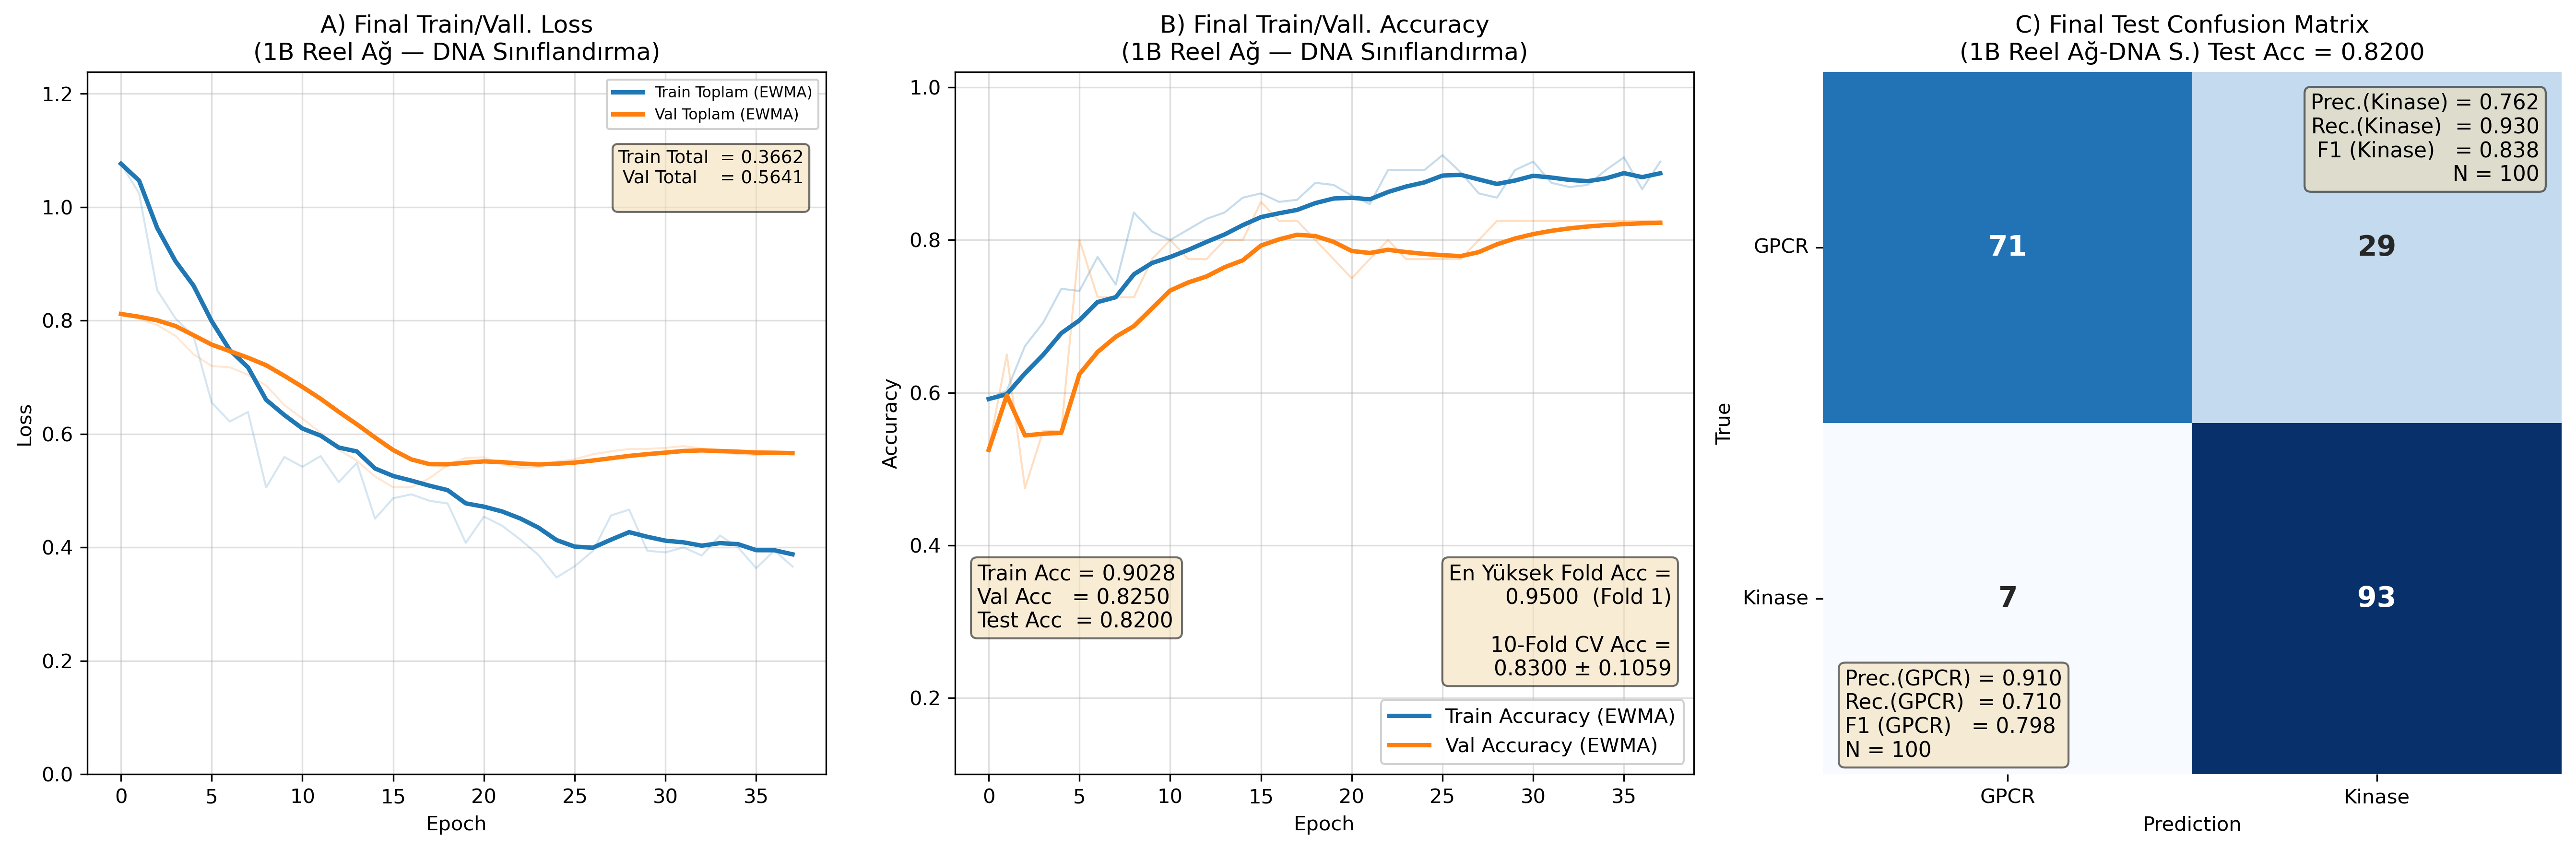

In [8]:
# =============================================================================
#   GRAFİK GÖRSELLEŞTİRME — 1B REEL DEĞERLİ CNN   [DNA / Kodon / AA ortak]
#
#   (temsil etiketi NPZ_YOLU'ndan otomatik algılar)
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_fscore_support, f1_score


# -------------------------------------------------------------------------
# 0.  Temsil etiketi  (DNA / Kodon / AA)
#    
# -------------------------------------------------------------------------
try:
    _kaynak = str(NPZ_YOLU).upper()
    if   "DNA"   in _kaynak: TEMSIL = "DNA"
    elif "KODON" in _kaynak: TEMSIL = "Kodon"
    elif "AA"    in _kaynak: TEMSIL = "AA"
    else:                    TEMSIL = "Reel"
except NameError:
    TEMSIL = "DNA"   # NPZ_YOLU tanımlı değilse elle


# -------------------------------------------------------------------------
# 1.  History anahtarları — 1B Reel CNN ile eşleşir
# -------------------------------------------------------------------------
LOSS_KEY     = "loss"
VAL_LOSS_KEY = "val_loss"
ACC_KEY      = "accuracy"
VAL_ACC_KEY  = "val_accuracy"


# -------------------------------------------------------------------------
# 2.  EWMA grafik yumuşatma
# -------------------------------------------------------------------------
def ewma_yumusat(dizi, alpha: float = 0.25) -> np.ndarray:
    return pd.Series(np.asarray(dizi, dtype=float)) \
             .ewm(alpha=alpha, adjust=True).mean().values


h = final_history.history

train_loss_ham = np.asarray(h[LOSS_KEY],     dtype=float)
val_loss_ham   = np.asarray(h[VAL_LOSS_KEY], dtype=float)
train_acc_ham  = np.asarray(h[ACC_KEY],      dtype=float)
val_acc_ham    = np.asarray(h[VAL_ACC_KEY],  dtype=float)

train_loss_sm = ewma_yumusat(train_loss_ham, alpha=0.25)
val_loss_sm   = ewma_yumusat(val_loss_ham,   alpha=0.25)
train_acc_sm  = ewma_yumusat(train_acc_ham,  alpha=0.25)
val_acc_sm    = ewma_yumusat(val_acc_ham,    alpha=0.25)


# -------------------------------------------------------------------------
# 3.  Son epoch değerleri
# -------------------------------------------------------------------------
train_loss_son = float(train_loss_ham[-1])
val_loss_son   = float(val_loss_ham[-1])
train_acc_son  = float(train_acc_ham[-1])
val_acc_son    = float(val_acc_ham[-1])


# -------------------------------------------------------------------------
# 4.  Test sınıf metrikleri
# -------------------------------------------------------------------------
prec, rec, f1, sup = precision_recall_fscore_support(
    y_test_int, y_test_pred,
    labels=[0, 1], average=None, zero_division=0)
macro_f1_test = f1_score(y_test_int, y_test_pred,
                         average="macro", zero_division=0)


# -------------------------------------------------------------------------
# 5.  CV özet — 1B Reel CNN sütun adları
# -------------------------------------------------------------------------
cv_acc_mean           = cv_df["acc"].mean()
cv_acc_std            = cv_df["acc"].std(ddof=1)
cv_best_val_loss_mean = cv_df["best_val_loss"].mean()
cv_best_val_loss_std  = cv_df["best_val_loss"].std(ddof=1)
cv_best_val_acc_mean  = cv_df["best_val_acc"].mean()
cv_best_val_acc_std   = cv_df["best_val_acc"].std(ddof=1)

en_yuksek_fold_acc = cv_df["acc"].max()
en_yuksek_fold_no  = int(cv_df.loc[cv_df["acc"].idxmax(), "fold"])
en_dusuk_fold_loss = cv_df["best_val_loss"].min()
en_dusuk_fold_no   = int(cv_df.loc[cv_df["best_val_loss"].idxmin(), "fold"])


# -------------------------------------------------------------------------
# 6.  Metin kutuları
# -------------------------------------------------------------------------
props = dict(boxstyle="round", facecolor="wheat", alpha=0.55)

# ── Panel A: Toplam loss son değerler ────────────────────────────────────
text_loss = "\n".join((
    f"Train Total  = {train_loss_son:.4f}",
    f"Val Total    = {val_loss_son:.4f}",
    "",))

# ── Panel B kutu 1: Train / Val / Test Acc ───────────────────────────────
text_acc_1 = "\n".join((
    f"Train Acc = {train_acc_son:.4f}",
    f"Val Acc   = {val_acc_son:.4f}",
    f"Test Acc  = {test_acc:.4f}",
))

# ── Panel B kutu 2: Fold istatistikleri ──────────────────────────────────
text_acc_2 = "\n".join((
    f"En Yüksek Fold Acc =",
    f"{en_yuksek_fold_acc:.4f}  (Fold {en_yuksek_fold_no})",
    "",
    f"10-Fold CV Acc =",
    f"{cv_acc_mean:.4f} ± {cv_acc_std:.4f}",
))

# ── Panel C: Sınıf kutuları ───────────────────────────────────────────────
text_gpcr = "\n".join((
    f"Prec.(GPCR) = {prec[0]:.3f}",
    f"Rec.(GPCR)  = {rec[0]:.3f}",
    f"F1 (GPCR)   = {f1[0]:.3f}",
    f"N = {sup[0]}",
))

text_kinase = "\n".join((
    f"Prec.(Kinase) = {prec[1]:.3f}",
    f"Rec.(Kinase)  = {rec[1]:.3f}",
    f"F1 (Kinase)   = {f1[1]:.3f}",
    f"N = {sup[1]}",
))


# -------------------------------------------------------------------------
# 7.  Grafik
# -------------------------------------------------------------------------
fig, ax = plt.subplots(1, 3, figsize=(18, 6), dpi=300)

C_TRAIN = "#1f77b4"   # mavi    — train
C_VAL   = "#ff7f0e"   # turuncu — val


# ==========================================================================
#  A) Toplam Loss
# ==========================================================================

# Ham eğriler (soluk)
ax[0].plot(train_loss_ham, color=C_TRAIN, linewidth=1.0, alpha=0.18, label="_nolegend_")
ax[0].plot(val_loss_ham,   color=C_VAL,   linewidth=1.0, alpha=0.18, label="_nolegend_")

# EWMA yumuşatılmış eğriler (kalın)
ax[0].plot(train_loss_sm, color=C_TRAIN, linewidth=2.2, label="Train Toplam (EWMA)")
ax[0].plot(val_loss_sm,   color=C_VAL,   linewidth=2.2, label="Val Toplam (EWMA)")

ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].grid(True, alpha=0.4)
ax[0].legend(loc="upper right", framealpha=0.9, fontsize=7.5)
ax[0].set_title(f"A) Final Train/Vall. Loss\n(1B Reel Ağ — {TEMSIL} Sınıflandırma)")

ymax_loss = max(np.nanmax(train_loss_ham), np.nanmax(val_loss_ham))
ax[0].set_ylim(0.0, max(0.5, ymax_loss * 1.15))

ax[0].text(0.97, 0.89, text_loss,
           transform=ax[0].transAxes, ha="right", va="top",
           fontsize=9.0, bbox=props)


# ==========================================================================
#  B) Accuracy
# ==========================================================================
ax[1].plot(train_acc_ham, color=C_TRAIN, linewidth=1.0, alpha=0.25, label="_nolegend_")
ax[1].plot(val_acc_ham,   color=C_VAL,   linewidth=1.0, alpha=0.25, label="_nolegend_")
ax[1].plot(train_acc_sm,  color=C_TRAIN, linewidth=2.2, label="Train Accuracy (EWMA)")
ax[1].plot(val_acc_sm,    color=C_VAL,   linewidth=2.2, label="Val Accuracy (EWMA)")

ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Accuracy")
ax[1].grid(True, alpha=0.4)
ax[1].legend(loc="lower right", framealpha=0.9)
ax[1].set_title(f"B) Final Train/Vall. Accuracy\n(1B Reel Ağ — {TEMSIL} Sınıflandırma)")
ax[1].set_ylim(0.1, 1.02)

# Kutu 1: Train / Val / Test Acc — sol alt
ax[1].text(0.03, 0.30, text_acc_1,
           transform=ax[1].transAxes, ha="left", va="top",
           fontsize=10.5, bbox=props)

# Kutu 2: Fold istatistikleri — sağ alt
ax[1].text(0.97, 0.30, text_acc_2,
           transform=ax[1].transAxes, ha="right", va="top",
           fontsize=10.5, bbox=props)


# ==========================================================================
#  C) Confusion Matrix
# ==========================================================================
sns.heatmap(test_cm, annot=True, fmt="d", cmap="Blues",
            cbar=False, ax=ax[2],
            annot_kws={"size": 14, "weight": "bold"})

ax[2].set_xlabel("Prediction")
ax[2].set_ylabel("True")
ax[2].set_title(
    f"C) Final Test Confusion Matrix\n(1B Reel Ağ-{TEMSIL} S.) Test Acc = {test_acc:.4f}")
ax[2].set_xticklabels([SINIF_ADLARI[0], SINIF_ADLARI[1]])
ax[2].set_yticklabels([SINIF_ADLARI[0], SINIF_ADLARI[1]], rotation=0)

ax[2].text(0.03, 0.15, text_gpcr,
           transform=ax[2].transAxes, ha="left", va="top",
           fontsize=10.5, bbox=props)
ax[2].text(0.97, 0.97, text_kinase,
           transform=ax[2].transAxes, ha="right", va="top",
           fontsize=10.5, bbox=props)


plt.tight_layout()
plt.savefig(f"reel_1dcnn_{TEMSIL.lower()}_gorsellestirme.png",
            dpi=600, bbox_inches="tight")
plt.show()

## 2. Adım: 1B RD EYSA ile tam sayı değerli KODON dizisi sınıflandırma:
- Daha önce karşılaştırma amaçlı literatürde bilinen reel değerli kodlama yöntemleri kullanılarak tamsayılara sayılara kodlanmış KODON dizilerine ait 400 train ve 200 test veri örneği kullanılarak kinaz (1) ve GPCR (0) protein aileleri 1B RD EYSA ile sınıflandırılmaktadır.
- 400 train örnek üzerinde 10-fold cross validation ile model değerlendirilir. Ardından aynı veri havuzu kullanılarak model yeniden eğitilir ve 2. sayfadaki 200 bağımsız örnek üzerinde nihai test yapılır.
- Eğitim (train) ve Doğrulama (Val.) ve Son olarak Final Test için Accuracy oranları hesaplanmakta ve her iki sınıf için ayrı ayrı Precision/Recall/F1 hesaplanmaktadır.
- Sonuçlar grafiklerle görselleştirilmektedir.

In [9]:
# ============================================
#   1B EVRİŞİMLİ REEL DEĞERLİ YSA (RDYSA-1D) — Kodon
#   Veri kaynağı: cds_KODON_Reel_L900.npz   
# --------------------------------------------
# 1) 400 örnek üzerinde 10-fold katmanlı CV
# 2) Final model: 400 örneği %90 train + %10 val olarak eğitilir
# 3) Ayrı 200 örnek üzerinde final test yapılır
# GPCR = 0, Kinase = 1
#
# ============================================

import time
import random
import logging
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support
)

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import (
    Conv1D, Flatten, Dense, Dropout, BatchNormalization,
    Input, MaxPooling1D
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, TerminateOnNaN
from tensorflow.keras.regularizers import l2


import warnings

warnings.filterwarnings(
    "ignore",
    category=UserWarning,
    module=r"scipy\.stats\._morestats"
)

# TF retracing/info uyarılarını sustur
tf.get_logger().setLevel(logging.ERROR)

# ------------------------------------------------------------
# Seed
# ------------------------------------------------------------
def yeni_run_seedi() -> int:
    return int(time.time() * 1000) % 10_000_000 + random.randint(0, 100_000)


RUN_SEED = yeni_run_seedi()
SPLIT_SEED = 42   # 12 script'te de AYNI;
print(f"[INFO] Bu run için kullanılan seed: {RUN_SEED}")

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(RUN_SEED)
np.random.seed(RUN_SEED)
random.seed(RUN_SEED)


# ------------------------------------------------------------
# Veri bilgisi
# ------------------------------------------------------------
NPZ_YOLU = r"C:\Users\matya\cds_KODON_Reel_L900.npz"

SINIF_ADLARI = {0: "GPCR", 1: "Kinase"}

# Final eğitim için train/val ayırma oranı
VAL_SIZE = 0.10   # 400 örneğin 40 val, 360 train

CV_CIKTI_XLSX = "reel_1dcnn_kodon_cv_10_fold.xlsx"

# ------------------------------------------------------------
# Veri okuma  (.npz — )

# ------------------------------------------------------------
def veriyi_yukle_npz_reel(npz_yolu):
    d = np.load(npz_yolu, allow_pickle=False)

    def al(k):
        if k not in d.files:
            raise KeyError(f"'{k}' anahtarı .npz içinde yok. Mevcut: {list(d.files)}")
        return d[k]

    X_tr = al("X_egitim").astype(np.float32)   # kategori kodu (kodon 0..63; büyüklük değil)
    X_te = al("X_test").astype(np.float32)
    yi_tr = al("y_egitim").astype(int)
    yi_te = al("y_test").astype(int)
    return X_tr, yi_tr, X_te, yi_te


X_full_train, y_full_train_int, X_test, y_test_int = veriyi_yukle_npz_reel(NPZ_YOLU)

y_full_train = to_categorical(y_full_train_int, num_classes=2)
y_test = to_categorical(y_test_int, num_classes=2)

print("=== VERI BILGISI ===")
print(f"CV havuzu   : {X_full_train.shape[0]}  (girdi boyutu={X_full_train.shape[1]})")
print(f"Final test  : {X_test.shape[0]}")
print(f"GPCR/Kinase : egitim {np.sum(y_full_train_int==0)}/{np.sum(y_full_train_int==1)}  "
      f"test {np.sum(y_test_int==0)}/{np.sum(y_test_int==1)}")
print("====================\n")


# ------------------------------------------------------------
# Model
# ------------------------------------------------------------
def modeli_kur(giris_uzunlugu: int, seed: int) -> Model:
    tf.keras.utils.set_random_seed(seed)

    input_layer = Input(shape=(giris_uzunlugu, 1), name="input_1d")

    conv1 = Conv1D(
        filters=16,
        kernel_size=5,
        activation="relu",
        padding="same",
        kernel_regularizer=l2(0.001),
        name="conv1"
    )(input_layer)
    conv1 = BatchNormalization(name="bn1")(conv1)
    conv1 = MaxPooling1D(pool_size=2, name="pool1")(conv1)
    conv1 = Dropout(0.2, name="drop1")(conv1)

    conv2 = Conv1D(
        filters=16,
        kernel_size=3,
        activation="relu",
        padding="same",
        kernel_regularizer=l2(0.001),
        name="conv2"
    )(conv1)
    conv2 = BatchNormalization(name="bn2")(conv2)
    conv2 = MaxPooling1D(pool_size=2, name="pool2")(conv2)
    conv2 = Dropout(0.2, name="drop2")(conv2)

    conv3 = Conv1D(
        filters=32,
        kernel_size=3,
        activation="relu",
        padding="same",
        kernel_regularizer=l2(0.001),
        name="conv3"
    )(conv2)
    conv3 = BatchNormalization(name="bn3")(conv3)
    conv3 = MaxPooling1D(pool_size=2, name="pool3")(conv3)
    conv3 = Dropout(0.3, name="drop3")(conv3)

    flattened = Flatten(name="flatten")(conv3)

    fc1 = Dense(
        32,
        activation="relu",
        kernel_regularizer=l2(0.001),
        name="fc1"
    )(flattened)
    fc1 = BatchNormalization(name="bn_fc1")(fc1)
    fc1 = Dropout(0.20, name="drop_fc1")(fc1)

    fc2 = Dense(
        16,
        activation="relu",
        kernel_regularizer=l2(0.001),
        name="fc2"
    )(fc1)
    fc2 = BatchNormalization(name="bn_fc2")(fc2)
    fc2 = Dropout(0.20, name="drop_fc2")(fc2)

    output_layer = Dense(2, activation="softmax", name="output")(fc2)

    model = Model(inputs=input_layer, outputs=output_layer)

    model.compile(
        optimizer=Adam(learning_rate=2e-4),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


# ------------------------------------------------------------
# 10-Fold/katmanlı Çapraz Doğrulama-CV
# ------------------------------------------------------------
N_SPLITS = 10
EPOCHS = 100
BATCH_SIZE = 16

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SPLIT_SEED)
fold_sonuclari = []
histories = []

for fold_no, (train_idx, val_idx) in enumerate(skf.split(X_full_train, y_full_train_int), start=1):
    print(f"\n================ FOLD {fold_no}/{N_SPLITS} ================")

    fold_seed = RUN_SEED + fold_no * 100

    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(fold_seed)
    np.random.seed(fold_seed)
    random.seed(fold_seed)

    X_train_fold = X_full_train[train_idx]
    X_val_fold   = X_full_train[val_idx]

    y_train_fold_int = y_full_train_int[train_idx]
    y_val_fold_int   = y_full_train_int[val_idx]

    y_train_fold = y_full_train[train_idx]
    y_val_fold   = y_full_train[val_idx]

    scaler = StandardScaler()
    X_train_fold = scaler.fit_transform(X_train_fold)
    X_val_fold   = scaler.transform(X_val_fold)

    # Conv1D için kanal ekseni
    X_train_fold = X_train_fold[..., np.newaxis]
    X_val_fold   = X_val_fold[..., np.newaxis]

    # class weight
    classes = np.array([0, 1])
    weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=y_train_fold_int
    )
    class_weight = {0: float(weights[0]), 1: float(weights[1])}

    print(f"Train boyutu      : {X_train_fold.shape[0]}")
    print(f"Validation boyutu : {X_val_fold.shape[0]}")
    print(f"class_weight      : {class_weight}")

    model = modeli_kur(giris_uzunlugu=X_train_fold.shape[1], seed=fold_seed)

    callbacks = [
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=5,
            min_lr=1e-6,
            verbose=0
        ),
        EarlyStopping(
            monitor="val_loss",
            patience=22,
            restore_best_weights=True,
            verbose=0
        ),
        TerminateOnNaN()
    ]

    history = model.fit(
        X_train_fold, y_train_fold,
        validation_data=(X_val_fold, y_val_fold),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=0,
        class_weight=class_weight
    )

    histories.append(history.history)

    y_val_pred_prob = model(X_val_fold, training=False).numpy()
    y_val_pred = np.argmax(y_val_pred_prob, axis=1)

    fold_acc = accuracy_score(y_val_fold_int, y_val_pred)

    prec_cls, rec_cls, f1_cls, sup_cls = precision_recall_fscore_support(
        y_val_fold_int,
        y_val_pred,
        labels=[0, 1],
        average=None,
        zero_division=0
    )

    macro_prec, macro_rec, macro_f1, _ = precision_recall_fscore_support(
        y_val_fold_int,
        y_val_pred,
        average="macro",
        zero_division=0
    )

    fold_dict = {
        "fold": fold_no,
        "acc": fold_acc,
        "macro_precision": macro_prec,
        "macro_recall": macro_rec,
        "macro_f1": macro_f1,
        "gpcr_precision": prec_cls[0],
        "gpcr_recall": rec_cls[0],
        "gpcr_f1": f1_cls[0],
        "gpcr_support": sup_cls[0],
        "kinase_precision": prec_cls[1],
        "kinase_recall": rec_cls[1],
        "kinase_f1": f1_cls[1],
        "kinase_support": sup_cls[1],
        "best_val_loss": float(np.min(history.history["val_loss"])),
        "best_val_acc": float(np.max(history.history["val_accuracy"])),
        "epoch_sayisi": len(history.history["loss"])
    }
    fold_sonuclari.append(fold_dict)

    print(f"Fold Accuracy      : {fold_acc:.4f}")
    print(f"Fold Macro F1      : {macro_f1:.4f}")
    print(f"GPCR   F1          : {f1_cls[0]:.4f}")
    print(f"Kinase F1          : {f1_cls[1]:.4f}")
    print(f"Best Val Loss      : {fold_dict['best_val_loss']:.4f}")
    print(f"Best Val Acc       : {fold_dict['best_val_acc']:.4f}")
    print(f"Epoch Sayisi       : {fold_dict['epoch_sayisi']}")


# ------------------------------------------------------------
# CV sonuçları
# ------------------------------------------------------------
cv_df = pd.DataFrame(fold_sonuclari)

print("\n================ 10-FOLD CV SONUCLARI =================")
print(
    cv_df[[
        "fold", "acc", "macro_precision", "macro_recall", "macro_f1",
        "gpcr_precision", "gpcr_recall", "gpcr_f1",
        "kinase_precision", "kinase_recall", "kinase_f1",
        "best_val_loss", "best_val_acc", "epoch_sayisi"
    ]].round(4).to_string(index=False)
)

print("\n================ CV ORTALAMA ± STD =================")
for kolon in [
    "acc", "macro_precision", "macro_recall", "macro_f1",
    "gpcr_precision", "gpcr_recall", "gpcr_f1",
    "kinase_precision", "kinase_recall", "kinase_f1",
    "best_val_loss", "best_val_acc", "epoch_sayisi"
]:
    ort = cv_df[kolon].mean()
    std = cv_df[kolon].std(ddof=1)
    print(f"{kolon:18s}: {ort:.4f} ± {std:.4f}")

cv_df.to_excel(CV_CIKTI_XLSX, index=False)
print(f"\n[INFO] CV sonuçları kaydedildi: {CV_CIKTI_XLSX}")


# ------------------------------------------------------------
# Final model eğitimi
# 400 örnek : %90 train + %10 val
# ------------------------------------------------------------
print("\n================ FINAL MODEL EGITIMI =================")

final_seed = RUN_SEED + 9999

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(final_seed)
np.random.seed(final_seed)
random.seed(final_seed)

# 90/10 stratified split
X_train_final, X_val_final, \
y_train_final, y_val_final, \
y_train_final_int, y_val_final_int = train_test_split(
    X_full_train,
    y_full_train,
    y_full_train_int,
    test_size=VAL_SIZE,
    stratify=y_full_train_int,
    random_state=final_seed
)

print(f"[INFO] Final train boyutu : {X_train_final.shape[0]}")
print(f"[INFO] Final val   boyutu : {X_val_final.shape[0]}")
print(f"[INFO] Test         boyutu: {X_test.shape[0]}")

# Scaler sadece train üzerinde fit edilir; val ve test transform edilir
scaler_final = StandardScaler()
X_train_final_scaled = scaler_final.fit_transform(X_train_final)
X_val_final_scaled   = scaler_final.transform(X_val_final)
X_test_scaled        = scaler_final.transform(X_test)

# Conv1D için kanal ekseni
X_train_final_scaled = X_train_final_scaled[..., np.newaxis]
X_val_final_scaled   = X_val_final_scaled[..., np.newaxis]
X_test_scaled        = X_test_scaled[..., np.newaxis]

# Final class weight - sadece final train üzerinden hesaplanır
classes = np.array([0, 1])
weights_final = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_final_int
)
class_weight_final = {0: float(weights_final[0]), 1: float(weights_final[1])}
print(f"[INFO] Final class_weight: {class_weight_final}")

final_model = modeli_kur(giris_uzunlugu=X_train_final_scaled.shape[1], seed=final_seed)

final_callbacks = [
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=0
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=22,
        restore_best_weights=True,
        verbose=0
    ),
    TerminateOnNaN()
]

final_history = final_model.fit(
    X_train_final_scaled, y_train_final,
    validation_data=(X_val_final_scaled, y_val_final),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1,
    callbacks=final_callbacks,
    class_weight=class_weight_final
)

# Final eğitim özeti
final_best_val_loss = float(np.min(final_history.history["val_loss"]))
final_best_val_acc  = float(np.max(final_history.history["val_accuracy"]))
final_epoch_sayisi  = len(final_history.history["loss"])
print(f"\n[INFO] Final eğitim epoch sayısı : {final_epoch_sayisi}")
print(f"[INFO] Final best val_loss       : {final_best_val_loss:.4f}")
print(f"[INFO] Final best val_accuracy   : {final_best_val_acc:.4f}")


# ------------------------------------------------------------
# Final test
# ------------------------------------------------------------
y_test_pred_prob = final_model(X_test_scaled, training=False).numpy()
y_test_pred = np.argmax(y_test_pred_prob, axis=1)

# Loss ve accuracy'yi manuel hesaplıyoruz (retracing yapmamak için)
test_loss = float(
    tf.keras.losses.categorical_crossentropy(y_test, y_test_pred_prob).numpy().mean()
)
test_acc_eval = float((y_test_pred == y_test_int).mean())
print("\n[INFO] Final test çıktısı: "
      f"[loss={test_loss:.4f}, acc={test_acc_eval:.4f}]")

test_cm = confusion_matrix(y_test_int, y_test_pred, labels=[0, 1])
test_acc = accuracy_score(y_test_int, y_test_pred)

test_prec_cls, test_rec_cls, test_f1_cls, test_sup_cls = precision_recall_fscore_support(
    y_test_int,
    y_test_pred,
    labels=[0, 1],
    average=None,
    zero_division=0
)

test_macro_prec, test_macro_rec, test_macro_f1, _ = precision_recall_fscore_support(
    y_test_int,
    y_test_pred,
    average="macro",
    zero_division=0
)

print("\n================ FINAL TEST SONUCU =================")
print("Confusion Matrix:\n", test_cm)
print(f"Test Accuracy     : {test_acc:.4f}")
print(f"Test Macro Prec   : {test_macro_prec:.4f}")
print(f"Test Macro Recall : {test_macro_rec:.4f}")
print(f"Test Macro F1     : {test_macro_f1:.4f}\n")

for i, lab in enumerate([0, 1]):
    print(
        f"- {SINIF_ADLARI[lab]} (label={lab}) | "
        f"Precision: {test_prec_cls[i]:.4f} | "
        f"Recall: {test_rec_cls[i]:.4f} | "
        f"F1: {test_f1_cls[i]:.4f} | "
        f"Support: {test_sup_cls[i]}"
    )

[INFO] Bu run için kullanılan seed: 7147936
=== VERI BILGISI ===
CV havuzu   : 400  (girdi boyutu=300)
Final test  : 200
GPCR/Kinase : egitim 200/200  test 100/100


================ FOLD 1/10 ================
Train boyutu      : 360
Validation boyutu : 40
class_weight      : {0: 1.0, 1: 1.0}
Fold Accuracy      : 0.8500
Fold Macro F1      : 0.8500
GPCR   F1          : 0.8500
Kinase F1          : 0.8500
Best Val Loss      : 0.3675
Best Val Acc       : 0.9000
Epoch Sayisi       : 77

================ FOLD 2/10 ================
Train boyutu      : 360
Validation boyutu : 40
class_weight      : {0: 1.0, 1: 1.0}
Fold Accuracy      : 0.9000
Fold Macro F1      : 0.8990
GPCR   F1          : 0.9091
Kinase F1          : 0.8889
Best Val Loss      : 0.4930
Best Val Acc       : 0.9000
Epoch Sayisi       : 100

================ FOLD 3/10 ================
Train boyutu      : 360
Validation boyutu : 40
class_weight      : {0: 1.0, 1: 1.0}
Fold Accuracy      : 0.7750
Fold Macro F1      : 0.7679
GPCR   

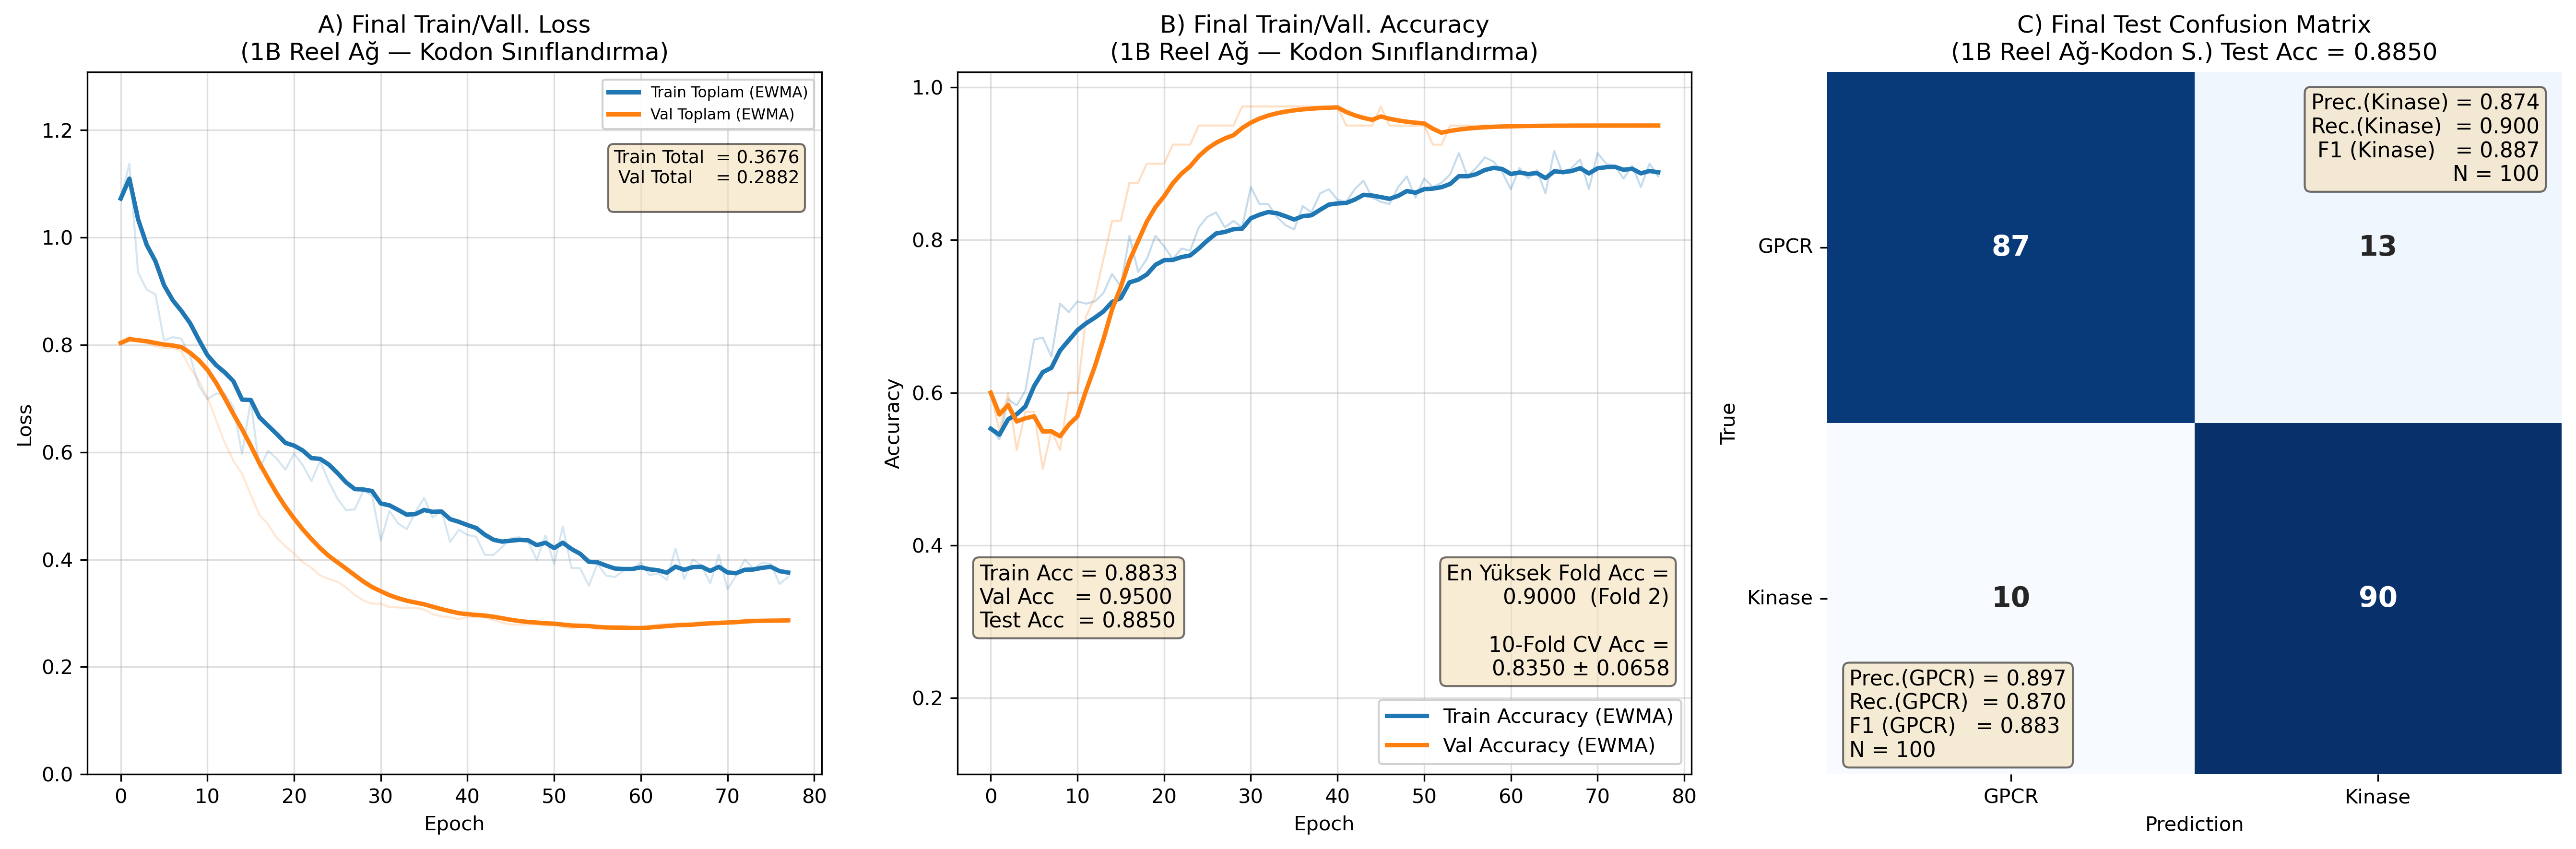

In [10]:
# =============================================================================
#   GRAFİK GÖRSELLEŞTİRME — 1B REEL DEĞERLİ CNN   [DNA / Kodon / AA ortak]
#
#   (temsil etiketi NPZ_YOLU'ndan otomatik algılar)
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_fscore_support, f1_score


# -------------------------------------------------------------------------
# 0.  Temsil etiketi  (DNA / Kodon / AA)
#     Ağ scriptindeki NPZ_YOLU'ndan otomatik algılanır; yoksa elle ayarla.
# -------------------------------------------------------------------------
try:
    _kaynak = str(NPZ_YOLU).upper()
    if   "DNA"   in _kaynak: TEMSIL = "DNA"
    elif "KODON" in _kaynak: TEMSIL = "Kodon"
    elif "AA"    in _kaynak: TEMSIL = "AA"
    else:                    TEMSIL = "Reel"
except NameError:
    TEMSIL = "DNA"   # NPZ_YOLU tanımlı değilse elle

# -------------------------------------------------------------------------
# 1.  History anahtarları — 1B Reel CNN ile eşleşir
# -------------------------------------------------------------------------
LOSS_KEY     = "loss"
VAL_LOSS_KEY = "val_loss"
ACC_KEY      = "accuracy"
VAL_ACC_KEY  = "val_accuracy"


# -------------------------------------------------------------------------
# 2.  EWMA grafik yumuşatma
# -------------------------------------------------------------------------
def ewma_yumusat(dizi, alpha: float = 0.25) -> np.ndarray:
    return pd.Series(np.asarray(dizi, dtype=float)) \
             .ewm(alpha=alpha, adjust=True).mean().values


h = final_history.history

train_loss_ham = np.asarray(h[LOSS_KEY],     dtype=float)
val_loss_ham   = np.asarray(h[VAL_LOSS_KEY], dtype=float)
train_acc_ham  = np.asarray(h[ACC_KEY],      dtype=float)
val_acc_ham    = np.asarray(h[VAL_ACC_KEY],  dtype=float)

train_loss_sm = ewma_yumusat(train_loss_ham, alpha=0.25)
val_loss_sm   = ewma_yumusat(val_loss_ham,   alpha=0.25)
train_acc_sm  = ewma_yumusat(train_acc_ham,  alpha=0.25)
val_acc_sm    = ewma_yumusat(val_acc_ham,    alpha=0.25)


# -------------------------------------------------------------------------
# 3.  Son epoch değerleri
# -------------------------------------------------------------------------
train_loss_son = float(train_loss_ham[-1])
val_loss_son   = float(val_loss_ham[-1])
train_acc_son  = float(train_acc_ham[-1])
val_acc_son    = float(val_acc_ham[-1])


# -------------------------------------------------------------------------
# 4.  Test sınıf metrikleri
# -------------------------------------------------------------------------
prec, rec, f1, sup = precision_recall_fscore_support(
    y_test_int, y_test_pred,
    labels=[0, 1], average=None, zero_division=0)
macro_f1_test = f1_score(y_test_int, y_test_pred,
                         average="macro", zero_division=0)


# -------------------------------------------------------------------------
# 5.  CV özet — 1B Reel CNN sütun adları
# -------------------------------------------------------------------------
cv_acc_mean           = cv_df["acc"].mean()
cv_acc_std            = cv_df["acc"].std(ddof=1)
cv_best_val_loss_mean = cv_df["best_val_loss"].mean()
cv_best_val_loss_std  = cv_df["best_val_loss"].std(ddof=1)
cv_best_val_acc_mean  = cv_df["best_val_acc"].mean()
cv_best_val_acc_std   = cv_df["best_val_acc"].std(ddof=1)

en_yuksek_fold_acc = cv_df["acc"].max()
en_yuksek_fold_no  = int(cv_df.loc[cv_df["acc"].idxmax(), "fold"])
en_dusuk_fold_loss = cv_df["best_val_loss"].min()
en_dusuk_fold_no   = int(cv_df.loc[cv_df["best_val_loss"].idxmin(), "fold"])


# -------------------------------------------------------------------------
# 6.  Metin kutuları
# -------------------------------------------------------------------------
props = dict(boxstyle="round", facecolor="wheat", alpha=0.55)

# ── Panel A: Toplam loss son değerler ────────────────────────────────────
text_loss = "\n".join((
    f"Train Total  = {train_loss_son:.4f}",
    f"Val Total    = {val_loss_son:.4f}",
    "",))

# ── Panel B kutu 1: Train / Val / Test Acc ───────────────────────────────
text_acc_1 = "\n".join((
    f"Train Acc = {train_acc_son:.4f}",
    f"Val Acc   = {val_acc_son:.4f}",
    f"Test Acc  = {test_acc:.4f}",
))

# ── Panel B kutu 2: Fold istatistikleri ──────────────────────────────────
text_acc_2 = "\n".join((
    f"En Yüksek Fold Acc =",
    f"{en_yuksek_fold_acc:.4f}  (Fold {en_yuksek_fold_no})",
    "",
    f"10-Fold CV Acc =",
    f"{cv_acc_mean:.4f} ± {cv_acc_std:.4f}",
))

# ── Panel C: Sınıf kutuları ───────────────────────────────────────────────
text_gpcr = "\n".join((
    f"Prec.(GPCR) = {prec[0]:.3f}",
    f"Rec.(GPCR)  = {rec[0]:.3f}",
    f"F1 (GPCR)   = {f1[0]:.3f}",
    f"N = {sup[0]}",
))

text_kinase = "\n".join((
    f"Prec.(Kinase) = {prec[1]:.3f}",
    f"Rec.(Kinase)  = {rec[1]:.3f}",
    f"F1 (Kinase)   = {f1[1]:.3f}",
    f"N = {sup[1]}",
))


# -------------------------------------------------------------------------
# 7.  Grafik
# -------------------------------------------------------------------------
fig, ax = plt.subplots(1, 3, figsize=(18, 6), dpi=300)

C_TRAIN = "#1f77b4"   # mavi    — train
C_VAL   = "#ff7f0e"   # turuncu — val


# ==========================================================================
#  A) Toplam Loss
# ==========================================================================

# Ham eğriler (soluk)
ax[0].plot(train_loss_ham, color=C_TRAIN, linewidth=1.0, alpha=0.18, label="_nolegend_")
ax[0].plot(val_loss_ham,   color=C_VAL,   linewidth=1.0, alpha=0.18, label="_nolegend_")

# EWMA yumuşatılmış eğriler (kalın)
ax[0].plot(train_loss_sm, color=C_TRAIN, linewidth=2.2, label="Train Toplam (EWMA)")
ax[0].plot(val_loss_sm,   color=C_VAL,   linewidth=2.2, label="Val Toplam (EWMA)")

ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].grid(True, alpha=0.4)
ax[0].legend(loc="upper right", framealpha=0.9, fontsize=7.5)
ax[0].set_title(f"A) Final Train/Vall. Loss\n(1B Reel Ağ — {TEMSIL} Sınıflandırma)")

ymax_loss = max(np.nanmax(train_loss_ham), np.nanmax(val_loss_ham))
ax[0].set_ylim(0.0, max(0.5, ymax_loss * 1.15))

ax[0].text(0.97, 0.89, text_loss,
           transform=ax[0].transAxes, ha="right", va="top",
           fontsize=9.0, bbox=props)


# ==========================================================================
#  B) Accuracy
# ==========================================================================
ax[1].plot(train_acc_ham, color=C_TRAIN, linewidth=1.0, alpha=0.25, label="_nolegend_")
ax[1].plot(val_acc_ham,   color=C_VAL,   linewidth=1.0, alpha=0.25, label="_nolegend_")
ax[1].plot(train_acc_sm,  color=C_TRAIN, linewidth=2.2, label="Train Accuracy (EWMA)")
ax[1].plot(val_acc_sm,    color=C_VAL,   linewidth=2.2, label="Val Accuracy (EWMA)")

ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Accuracy")
ax[1].grid(True, alpha=0.4)
ax[1].legend(loc="lower right", framealpha=0.9)
ax[1].set_title(f"B) Final Train/Vall. Accuracy\n(1B Reel Ağ — {TEMSIL} Sınıflandırma)")
ax[1].set_ylim(0.1, 1.02)

# Kutu 1: Train / Val / Test Acc — sol alt
ax[1].text(0.03, 0.30, text_acc_1,
           transform=ax[1].transAxes, ha="left", va="top",
           fontsize=10.5, bbox=props)

# Kutu 2: Fold istatistikleri — sağ alt
ax[1].text(0.97, 0.30, text_acc_2,
           transform=ax[1].transAxes, ha="right", va="top",
           fontsize=10.5, bbox=props)


# ==========================================================================
#  C) Confusion Matrix
# ==========================================================================
sns.heatmap(test_cm, annot=True, fmt="d", cmap="Blues",
            cbar=False, ax=ax[2],
            annot_kws={"size": 14, "weight": "bold"})

ax[2].set_xlabel("Prediction")
ax[2].set_ylabel("True")
ax[2].set_title(
    f"C) Final Test Confusion Matrix\n(1B Reel Ağ-{TEMSIL} S.) Test Acc = {test_acc:.4f}")
ax[2].set_xticklabels([SINIF_ADLARI[0], SINIF_ADLARI[1]])
ax[2].set_yticklabels([SINIF_ADLARI[0], SINIF_ADLARI[1]], rotation=0)

ax[2].text(0.03, 0.15, text_gpcr,
           transform=ax[2].transAxes, ha="left", va="top",
           fontsize=10.5, bbox=props)
ax[2].text(0.97, 0.97, text_kinase,
           transform=ax[2].transAxes, ha="right", va="top",
           fontsize=10.5, bbox=props)


plt.tight_layout()
plt.savefig(f"reel_1dcnn_{TEMSIL.lower()}_gorsellestirme.png",
            dpi=600, bbox_inches="tight")
plt.show()

## 3. Adım: 1B RD EYSA ile tam sayı değerli AMİNO ASİT dizisi sınıflandırma:
- Daha önce karşılaştırma amaçlı literatürde bilinen reel değerli kodlama yöntemleri kullanılarak tamsayılara sayılara kodlanmış AMİNO ASİT dizilerine ait 400 train ve 200 test veri örneği kullanılarak kinaz (1) ve GPCR (0) protein aileleri 1B RD EYSA ile sınıflandırılmaktadır.
- 400 train örnek üzerinde 10-fold cross validation ile model değerlendirilir. Ardından aynı veri havuzu kullanılarak model yeniden eğitilir ve 2. sayfadaki 200 bağımsız örnek üzerinde nihai test yapılır.
- Eğitim (train) ve Doğrulama (Val.) ve Son olarak Final Test için Accuracy oranları hesaplanmakta ve her iki sınıf için ayrı ayrı Precision/Recall/F1 hesaplanmaktadır.
- Sonuçlar grafiklerle görselleştirilmektedir.

In [14]:
# ============================================
#   1B EVRİŞİMLİ REEL DEĞERLİ YSA (RDYSA-1D) — Amino asit
#   Veri kaynağı: AA_Reel_L300.npz   
# --------------------------------------------
# 1) 400 örnek üzerinde 10-fold katmanlı CV
# 2) Final model: 400 örneği %90 train + %10 val olarak eğitilir
# 3) Ayrı 200 örnek üzerinde final test yapılır
# GPCR = 0, Kinase = 1
#
#      veri okuma Excel'den .npz'ye geçirildi.
# ============================================

import time
import random
import logging
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support
)

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import (
    Conv1D, Flatten, Dense, Dropout, BatchNormalization,
    Input, MaxPooling1D
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, TerminateOnNaN
from tensorflow.keras.regularizers import l2


import warnings

warnings.filterwarnings(
    "ignore",
    category=UserWarning,
    module=r"scipy\.stats\._morestats"
)

# TF retracing/info uyarılarını sustur
tf.get_logger().setLevel(logging.ERROR)

# ------------------------------------------------------------
# Seed
# ------------------------------------------------------------
def yeni_run_seedi() -> int:
    return int(time.time() * 1000) % 10_000_000 + random.randint(0, 100_000)


RUN_SEED = yeni_run_seedi()
SPLIT_SEED = 42   # 12 script'te de AYNI;
print(f"[INFO] Bu run için kullanılan seed: {RUN_SEED}")

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(RUN_SEED)
np.random.seed(RUN_SEED)
random.seed(RUN_SEED)


# ------------------------------------------------------------
# Veri bilgisi
# ------------------------------------------------------------
NPZ_YOLU = r"C:\Users\matya\AA_Reel_L300.npz"

SINIF_ADLARI = {0: "GPCR", 1: "Kinase"}

# Final eğitim için train/val ayırma oranı
VAL_SIZE = 0.10   # 400 örneğin 40 val, 360 train

CV_CIKTI_XLSX = "reel_1dcnn_aa_cv_10_fold.xlsx"

# ------------------------------------------------------------
# Veri okuma  (.npz — bilgi notu ortak şeması)
#   X_egitim / X_test : int8 kategori kodu -> float32'e çevrilir
#   y_egitim / y_test : int8 etiket

# ------------------------------------------------------------
def veriyi_yukle_npz_reel(npz_yolu):
    d = np.load(npz_yolu, allow_pickle=False)

    def al(k):
        if k not in d.files:
            raise KeyError(f"'{k}' anahtarı .npz içinde yok. Mevcut: {list(d.files)}")
        return d[k]

    X_tr = al("X_egitim").astype(np.float32)   # kategori kodu 
    X_te = al("X_test").astype(np.float32)
    yi_tr = al("y_egitim").astype(int)
    yi_te = al("y_test").astype(int)
    return X_tr, yi_tr, X_te, yi_te


X_full_train, y_full_train_int, X_test, y_test_int = veriyi_yukle_npz_reel(NPZ_YOLU)

y_full_train = to_categorical(y_full_train_int, num_classes=2)
y_test = to_categorical(y_test_int, num_classes=2)

print("=== VERI BILGISI ===")
print(f"CV havuzu   : {X_full_train.shape[0]}  (girdi boyutu={X_full_train.shape[1]})")
print(f"Final test  : {X_test.shape[0]}")
print(f"GPCR/Kinase : egitim {np.sum(y_full_train_int==0)}/{np.sum(y_full_train_int==1)}  "
      f"test {np.sum(y_test_int==0)}/{np.sum(y_test_int==1)}")
print("====================\n")


# ------------------------------------------------------------
# Model
# ------------------------------------------------------------
def modeli_kur(giris_uzunlugu: int, seed: int) -> Model:
    tf.keras.utils.set_random_seed(seed)

    input_layer = Input(shape=(giris_uzunlugu, 1), name="input_1d")

    conv1 = Conv1D(
        filters=16,
        kernel_size=5,
        activation="relu",
        padding="same",
        kernel_regularizer=l2(0.001),
        name="conv1"
    )(input_layer)
    conv1 = BatchNormalization(name="bn1")(conv1)
    conv1 = MaxPooling1D(pool_size=2, name="pool1")(conv1)
    conv1 = Dropout(0.2, name="drop1")(conv1)

    conv2 = Conv1D(
        filters=16,
        kernel_size=3,
        activation="relu",
        padding="same",
        kernel_regularizer=l2(0.001),
        name="conv2"
    )(conv1)
    conv2 = BatchNormalization(name="bn2")(conv2)
    conv2 = MaxPooling1D(pool_size=2, name="pool2")(conv2)
    conv2 = Dropout(0.2, name="drop2")(conv2)

    conv3 = Conv1D(
        filters=32,
        kernel_size=3,
        activation="relu",
        padding="same",
        kernel_regularizer=l2(0.001),
        name="conv3"
    )(conv2)
    conv3 = BatchNormalization(name="bn3")(conv3)
    conv3 = MaxPooling1D(pool_size=2, name="pool3")(conv3)
    conv3 = Dropout(0.3, name="drop3")(conv3)

    flattened = Flatten(name="flatten")(conv3)

    fc1 = Dense(
        32,
        activation="relu",
        kernel_regularizer=l2(0.001),
        name="fc1"
    )(flattened)
    fc1 = BatchNormalization(name="bn_fc1")(fc1)
    fc1 = Dropout(0.20, name="drop_fc1")(fc1)

    fc2 = Dense(
        16,
        activation="relu",
        kernel_regularizer=l2(0.001),
        name="fc2"
    )(fc1)
    fc2 = BatchNormalization(name="bn_fc2")(fc2)
    fc2 = Dropout(0.20, name="drop_fc2")(fc2)

    output_layer = Dense(2, activation="softmax", name="output")(fc2)

    model = Model(inputs=input_layer, outputs=output_layer)

    model.compile(
        optimizer=Adam(learning_rate=2e-4),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


# ------------------------------------------------------------
# 10-Fold/katmanlı Çapraz Doğrulama-CV
# ------------------------------------------------------------
N_SPLITS = 10
EPOCHS = 100
BATCH_SIZE = 16

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SPLIT_SEED)
fold_sonuclari = []
histories = []

for fold_no, (train_idx, val_idx) in enumerate(skf.split(X_full_train, y_full_train_int), start=1):
    print(f"\n================ FOLD {fold_no}/{N_SPLITS} ================")

    fold_seed = RUN_SEED + fold_no * 100

    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(fold_seed)
    np.random.seed(fold_seed)
    random.seed(fold_seed)

    X_train_fold = X_full_train[train_idx]
    X_val_fold   = X_full_train[val_idx]

    y_train_fold_int = y_full_train_int[train_idx]
    y_val_fold_int   = y_full_train_int[val_idx]

    y_train_fold = y_full_train[train_idx]
    y_val_fold   = y_full_train[val_idx]

    scaler = StandardScaler()
    X_train_fold = scaler.fit_transform(X_train_fold)
    X_val_fold   = scaler.transform(X_val_fold)

    # Conv1D için kanal ekseni
    X_train_fold = X_train_fold[..., np.newaxis]
    X_val_fold   = X_val_fold[..., np.newaxis]

    # class weight
    classes = np.array([0, 1])
    weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=y_train_fold_int
    )
    class_weight = {0: float(weights[0]), 1: float(weights[1])}

    print(f"Train boyutu      : {X_train_fold.shape[0]}")
    print(f"Validation boyutu : {X_val_fold.shape[0]}")
    print(f"class_weight      : {class_weight}")

    model = modeli_kur(giris_uzunlugu=X_train_fold.shape[1], seed=fold_seed)

    callbacks = [
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=5,
            min_lr=1e-6,
            verbose=0
        ),
        EarlyStopping(
            monitor="val_loss",
            patience=22,
            restore_best_weights=True,
            verbose=0
        ),
        TerminateOnNaN()
    ]

    history = model.fit(
        X_train_fold, y_train_fold,
        validation_data=(X_val_fold, y_val_fold),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=0,
        class_weight=class_weight
    )

    histories.append(history.history)

    y_val_pred_prob = model(X_val_fold, training=False).numpy()
    y_val_pred = np.argmax(y_val_pred_prob, axis=1)

    fold_acc = accuracy_score(y_val_fold_int, y_val_pred)

    prec_cls, rec_cls, f1_cls, sup_cls = precision_recall_fscore_support(
        y_val_fold_int,
        y_val_pred,
        labels=[0, 1],
        average=None,
        zero_division=0
    )

    macro_prec, macro_rec, macro_f1, _ = precision_recall_fscore_support(
        y_val_fold_int,
        y_val_pred,
        average="macro",
        zero_division=0
    )

    fold_dict = {
        "fold": fold_no,
        "acc": fold_acc,
        "macro_precision": macro_prec,
        "macro_recall": macro_rec,
        "macro_f1": macro_f1,
        "gpcr_precision": prec_cls[0],
        "gpcr_recall": rec_cls[0],
        "gpcr_f1": f1_cls[0],
        "gpcr_support": sup_cls[0],
        "kinase_precision": prec_cls[1],
        "kinase_recall": rec_cls[1],
        "kinase_f1": f1_cls[1],
        "kinase_support": sup_cls[1],
        "best_val_loss": float(np.min(history.history["val_loss"])),
        "best_val_acc": float(np.max(history.history["val_accuracy"])),
        "epoch_sayisi": len(history.history["loss"])
    }
    fold_sonuclari.append(fold_dict)

    print(f"Fold Accuracy      : {fold_acc:.4f}")
    print(f"Fold Macro F1      : {macro_f1:.4f}")
    print(f"GPCR   F1          : {f1_cls[0]:.4f}")
    print(f"Kinase F1          : {f1_cls[1]:.4f}")
    print(f"Best Val Loss      : {fold_dict['best_val_loss']:.4f}")
    print(f"Best Val Acc       : {fold_dict['best_val_acc']:.4f}")
    print(f"Epoch Sayisi       : {fold_dict['epoch_sayisi']}")


# ------------------------------------------------------------
# CV sonuçları
# ------------------------------------------------------------
cv_df = pd.DataFrame(fold_sonuclari)

print("\n================ 10-FOLD CV SONUCLARI =================")
print(
    cv_df[[
        "fold", "acc", "macro_precision", "macro_recall", "macro_f1",
        "gpcr_precision", "gpcr_recall", "gpcr_f1",
        "kinase_precision", "kinase_recall", "kinase_f1",
        "best_val_loss", "best_val_acc", "epoch_sayisi"
    ]].round(4).to_string(index=False)
)

print("\n================ CV ORTALAMA ± STD =================")
for kolon in [
    "acc", "macro_precision", "macro_recall", "macro_f1",
    "gpcr_precision", "gpcr_recall", "gpcr_f1",
    "kinase_precision", "kinase_recall", "kinase_f1",
    "best_val_loss", "best_val_acc", "epoch_sayisi"
]:
    ort = cv_df[kolon].mean()
    std = cv_df[kolon].std(ddof=1)
    print(f"{kolon:18s}: {ort:.4f} ± {std:.4f}")

cv_df.to_excel(CV_CIKTI_XLSX, index=False)
print(f"\n[INFO] CV sonuçları kaydedildi: {CV_CIKTI_XLSX}")


# ------------------------------------------------------------
# Final model eğitimi
# 400 örnek : %90 train + %10 val
# ------------------------------------------------------------
print("\n================ FINAL MODEL EGITIMI =================")

final_seed = RUN_SEED + 9999

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(final_seed)
np.random.seed(final_seed)
random.seed(final_seed)

# 90/10 stratified split
X_train_final, X_val_final, \
y_train_final, y_val_final, \
y_train_final_int, y_val_final_int = train_test_split(
    X_full_train,
    y_full_train,
    y_full_train_int,
    test_size=VAL_SIZE,
    stratify=y_full_train_int,
    random_state=final_seed
)

print(f"[INFO] Final train boyutu : {X_train_final.shape[0]}")
print(f"[INFO] Final val   boyutu : {X_val_final.shape[0]}")
print(f"[INFO] Test         boyutu: {X_test.shape[0]}")

# Scaler sadece train üzerinde fit edilir; val ve test transform edilir
scaler_final = StandardScaler()
X_train_final_scaled = scaler_final.fit_transform(X_train_final)
X_val_final_scaled   = scaler_final.transform(X_val_final)
X_test_scaled        = scaler_final.transform(X_test)

# Conv1D için kanal ekseni
X_train_final_scaled = X_train_final_scaled[..., np.newaxis]
X_val_final_scaled   = X_val_final_scaled[..., np.newaxis]
X_test_scaled        = X_test_scaled[..., np.newaxis]

# Final class weight - sadece final train üzerinden hesaplanır
classes = np.array([0, 1])
weights_final = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_final_int
)
class_weight_final = {0: float(weights_final[0]), 1: float(weights_final[1])}
print(f"[INFO] Final class_weight: {class_weight_final}")

final_model = modeli_kur(giris_uzunlugu=X_train_final_scaled.shape[1], seed=final_seed)

final_callbacks = [
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=0
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=22,
        restore_best_weights=True,
        verbose=0
    ),
    TerminateOnNaN()
]

final_history = final_model.fit(
    X_train_final_scaled, y_train_final,
    validation_data=(X_val_final_scaled, y_val_final),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1,
    callbacks=final_callbacks,
    class_weight=class_weight_final
)

# Final eğitim özeti
final_best_val_loss = float(np.min(final_history.history["val_loss"]))
final_best_val_acc  = float(np.max(final_history.history["val_accuracy"]))
final_epoch_sayisi  = len(final_history.history["loss"])
print(f"\n[INFO] Final eğitim epoch sayısı : {final_epoch_sayisi}")
print(f"[INFO] Final best val_loss       : {final_best_val_loss:.4f}")
print(f"[INFO] Final best val_accuracy   : {final_best_val_acc:.4f}")


# ------------------------------------------------------------
# Final test
# ------------------------------------------------------------
y_test_pred_prob = final_model(X_test_scaled, training=False).numpy()
y_test_pred = np.argmax(y_test_pred_prob, axis=1)

# Loss ve accuracy'yi manuel hesaplıyoruz (retracing yapmamak için)
test_loss = float(
    tf.keras.losses.categorical_crossentropy(y_test, y_test_pred_prob).numpy().mean()
)
test_acc_eval = float((y_test_pred == y_test_int).mean())
print("\n[INFO] Final test çıktısı: "
      f"[loss={test_loss:.4f}, acc={test_acc_eval:.4f}]")

test_cm = confusion_matrix(y_test_int, y_test_pred, labels=[0, 1])
test_acc = accuracy_score(y_test_int, y_test_pred)

test_prec_cls, test_rec_cls, test_f1_cls, test_sup_cls = precision_recall_fscore_support(
    y_test_int,
    y_test_pred,
    labels=[0, 1],
    average=None,
    zero_division=0
)

test_macro_prec, test_macro_rec, test_macro_f1, _ = precision_recall_fscore_support(
    y_test_int,
    y_test_pred,
    average="macro",
    zero_division=0
)

print("\n================ FINAL TEST SONUCU =================")
print("Confusion Matrix:\n", test_cm)
print(f"Test Accuracy     : {test_acc:.4f}")
print(f"Test Macro Prec   : {test_macro_prec:.4f}")
print(f"Test Macro Recall : {test_macro_rec:.4f}")
print(f"Test Macro F1     : {test_macro_f1:.4f}\n")

for i, lab in enumerate([0, 1]):
    print(
        f"- {SINIF_ADLARI[lab]} (label={lab}) | "
        f"Precision: {test_prec_cls[i]:.4f} | "
        f"Recall: {test_rec_cls[i]:.4f} | "
        f"F1: {test_f1_cls[i]:.4f} | "
        f"Support: {test_sup_cls[i]}"
    )

[INFO] Bu run için kullanılan seed: 8094040
=== VERI BILGISI ===
CV havuzu   : 400  (girdi boyutu=300)
Final test  : 200
GPCR/Kinase : egitim 200/200  test 100/100


================ FOLD 1/10 ================
Train boyutu      : 360
Validation boyutu : 40
class_weight      : {0: 1.0, 1: 1.0}
Fold Accuracy      : 0.9250
Fold Macro F1      : 0.9250
GPCR   F1          : 0.9268
Kinase F1          : 0.9231
Best Val Loss      : 0.3674
Best Val Acc       : 0.9250
Epoch Sayisi       : 40

================ FOLD 2/10 ================
Train boyutu      : 360
Validation boyutu : 40
class_weight      : {0: 1.0, 1: 1.0}
Fold Accuracy      : 0.9500
Fold Macro F1      : 0.9500
GPCR   F1          : 0.9500
Kinase F1          : 0.9500
Best Val Loss      : 0.2376
Best Val Acc       : 0.9750
Epoch Sayisi       : 75

================ FOLD 3/10 ================
Train boyutu      : 360
Validation boyutu : 40
class_weight      : {0: 1.0, 1: 1.0}
Fold Accuracy      : 0.8000
Fold Macro F1      : 0.7954
GPCR   F

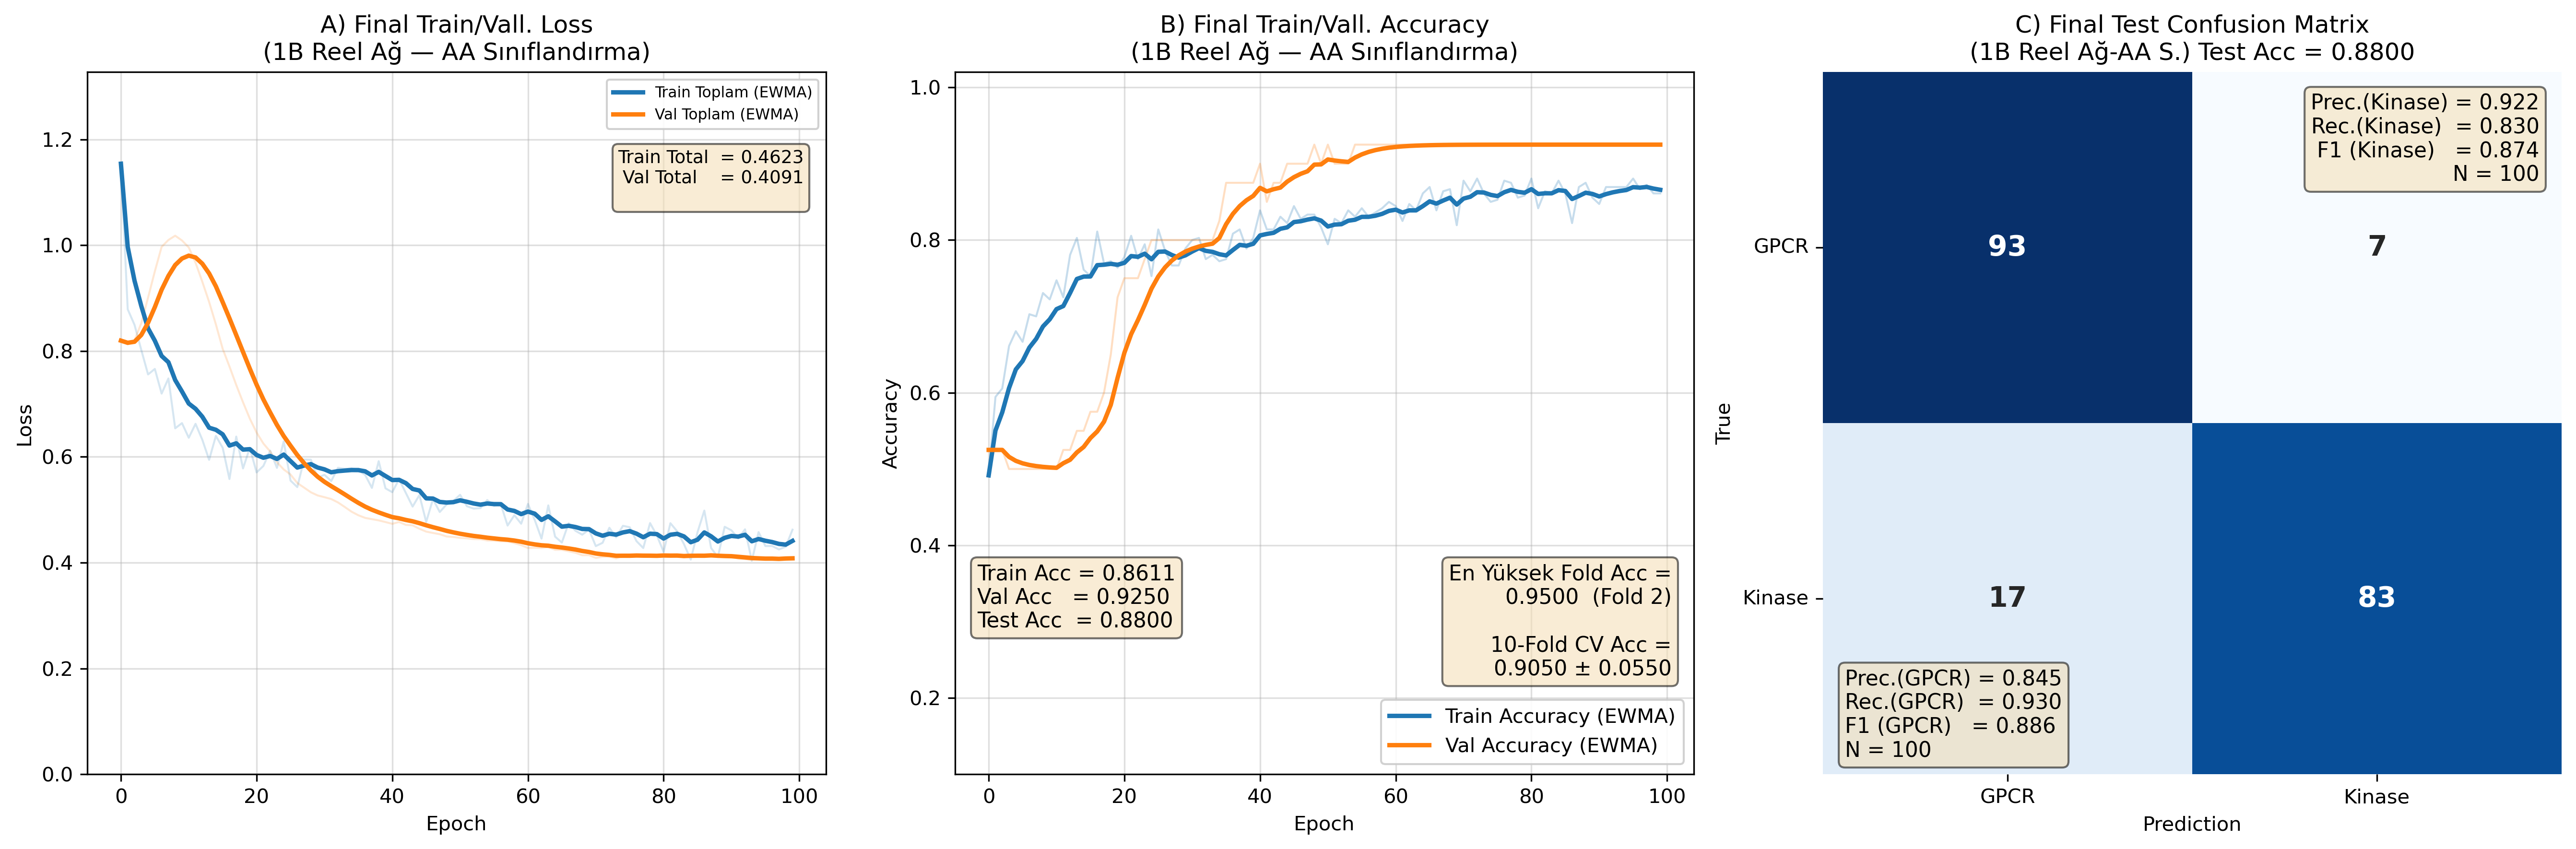

In [15]:
# =============================================================================
#   GRAFİK GÖRSELLEŞTİRME — 1B REEL DEĞERLİ CNN   [DNA / Kodon / AA ortak]
#
#   (temsil etiketi NPZ_YOLU'ndan otomatik algılar)
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_fscore_support, f1_score


# -------------------------------------------------------------------------
# 0.  Temsil etiketi  (DNA / Kodon / AA)
#     Ağ scriptindeki NPZ_YOLU'ndan otomatik algılanır; yoksa elle ayarla.
# -------------------------------------------------------------------------
try:
    _kaynak = str(NPZ_YOLU).upper()
    if   "DNA"   in _kaynak: TEMSIL = "DNA"
    elif "KODON" in _kaynak: TEMSIL = "Kodon"
    elif "AA"    in _kaynak: TEMSIL = "AA"
    else:                    TEMSIL = "Reel"
except NameError:
    TEMSIL = "DNA"   # NPZ_YOLU tanımlı değilse elle


# -------------------------------------------------------------------------
# 1.  History anahtarları — 1B Reel CNN ile eşleşir
# -------------------------------------------------------------------------
LOSS_KEY     = "loss"
VAL_LOSS_KEY = "val_loss"
ACC_KEY      = "accuracy"
VAL_ACC_KEY  = "val_accuracy"


# -------------------------------------------------------------------------
# 2.  EWMA grafik yumuşatma
# -------------------------------------------------------------------------
def ewma_yumusat(dizi, alpha: float = 0.25) -> np.ndarray:
    return pd.Series(np.asarray(dizi, dtype=float)) \
             .ewm(alpha=alpha, adjust=True).mean().values


h = final_history.history

train_loss_ham = np.asarray(h[LOSS_KEY],     dtype=float)
val_loss_ham   = np.asarray(h[VAL_LOSS_KEY], dtype=float)
train_acc_ham  = np.asarray(h[ACC_KEY],      dtype=float)
val_acc_ham    = np.asarray(h[VAL_ACC_KEY],  dtype=float)

train_loss_sm = ewma_yumusat(train_loss_ham, alpha=0.25)
val_loss_sm   = ewma_yumusat(val_loss_ham,   alpha=0.25)
train_acc_sm  = ewma_yumusat(train_acc_ham,  alpha=0.25)
val_acc_sm    = ewma_yumusat(val_acc_ham,    alpha=0.25)


# -------------------------------------------------------------------------
# 3.  Son epoch değerleri
# -------------------------------------------------------------------------
train_loss_son = float(train_loss_ham[-1])
val_loss_son   = float(val_loss_ham[-1])
train_acc_son  = float(train_acc_ham[-1])
val_acc_son    = float(val_acc_ham[-1])


# -------------------------------------------------------------------------
# 4.  Test sınıf metrikleri
# -------------------------------------------------------------------------
prec, rec, f1, sup = precision_recall_fscore_support(
    y_test_int, y_test_pred,
    labels=[0, 1], average=None, zero_division=0)
macro_f1_test = f1_score(y_test_int, y_test_pred,
                         average="macro", zero_division=0)


# -------------------------------------------------------------------------
# 5.  CV özet — 1B Reel CNN sütun adları
# -------------------------------------------------------------------------
cv_acc_mean           = cv_df["acc"].mean()
cv_acc_std            = cv_df["acc"].std(ddof=1)
cv_best_val_loss_mean = cv_df["best_val_loss"].mean()
cv_best_val_loss_std  = cv_df["best_val_loss"].std(ddof=1)
cv_best_val_acc_mean  = cv_df["best_val_acc"].mean()
cv_best_val_acc_std   = cv_df["best_val_acc"].std(ddof=1)

en_yuksek_fold_acc = cv_df["acc"].max()
en_yuksek_fold_no  = int(cv_df.loc[cv_df["acc"].idxmax(), "fold"])
en_dusuk_fold_loss = cv_df["best_val_loss"].min()
en_dusuk_fold_no   = int(cv_df.loc[cv_df["best_val_loss"].idxmin(), "fold"])


# -------------------------------------------------------------------------
# 6.  Metin kutuları
# -------------------------------------------------------------------------
props = dict(boxstyle="round", facecolor="wheat", alpha=0.55)

# ── Panel A: Toplam loss son değerler ────────────────────────────────────
text_loss = "\n".join((
    f"Train Total  = {train_loss_son:.4f}",
    f"Val Total    = {val_loss_son:.4f}",
    "",))

# ── Panel B kutu 1: Train / Val / Test Acc ───────────────────────────────
text_acc_1 = "\n".join((
    f"Train Acc = {train_acc_son:.4f}",
    f"Val Acc   = {val_acc_son:.4f}",
    f"Test Acc  = {test_acc:.4f}",
))

# ── Panel B kutu 2: Fold istatistikleri ──────────────────────────────────
text_acc_2 = "\n".join((
    f"En Yüksek Fold Acc =",
    f"{en_yuksek_fold_acc:.4f}  (Fold {en_yuksek_fold_no})",
    "",
    f"10-Fold CV Acc =",
    f"{cv_acc_mean:.4f} ± {cv_acc_std:.4f}",
))

# ── Panel C: Sınıf kutuları ───────────────────────────────────────────────
text_gpcr = "\n".join((
    f"Prec.(GPCR) = {prec[0]:.3f}",
    f"Rec.(GPCR)  = {rec[0]:.3f}",
    f"F1 (GPCR)   = {f1[0]:.3f}",
    f"N = {sup[0]}",
))

text_kinase = "\n".join((
    f"Prec.(Kinase) = {prec[1]:.3f}",
    f"Rec.(Kinase)  = {rec[1]:.3f}",
    f"F1 (Kinase)   = {f1[1]:.3f}",
    f"N = {sup[1]}",
))


# -------------------------------------------------------------------------
# 7.  Grafik
# -------------------------------------------------------------------------
fig, ax = plt.subplots(1, 3, figsize=(18, 6), dpi=300)

C_TRAIN = "#1f77b4"   # mavi    — train
C_VAL   = "#ff7f0e"   # turuncu — val


# ==========================================================================
#  A) Toplam Loss
# ==========================================================================

# Ham eğriler (soluk)
ax[0].plot(train_loss_ham, color=C_TRAIN, linewidth=1.0, alpha=0.18, label="_nolegend_")
ax[0].plot(val_loss_ham,   color=C_VAL,   linewidth=1.0, alpha=0.18, label="_nolegend_")

# EWMA yumuşatılmış eğriler (kalın)
ax[0].plot(train_loss_sm, color=C_TRAIN, linewidth=2.2, label="Train Toplam (EWMA)")
ax[0].plot(val_loss_sm,   color=C_VAL,   linewidth=2.2, label="Val Toplam (EWMA)")

ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].grid(True, alpha=0.4)
ax[0].legend(loc="upper right", framealpha=0.9, fontsize=7.5)
ax[0].set_title(f"A) Final Train/Vall. Loss\n(1B Reel Ağ — {TEMSIL} Sınıflandırma)")

ymax_loss = max(np.nanmax(train_loss_ham), np.nanmax(val_loss_ham))
ax[0].set_ylim(0.0, max(0.5, ymax_loss * 1.15))

ax[0].text(0.97, 0.89, text_loss,
           transform=ax[0].transAxes, ha="right", va="top",
           fontsize=9.0, bbox=props)


# ==========================================================================
#  B) Accuracy
# ==========================================================================
ax[1].plot(train_acc_ham, color=C_TRAIN, linewidth=1.0, alpha=0.25, label="_nolegend_")
ax[1].plot(val_acc_ham,   color=C_VAL,   linewidth=1.0, alpha=0.25, label="_nolegend_")
ax[1].plot(train_acc_sm,  color=C_TRAIN, linewidth=2.2, label="Train Accuracy (EWMA)")
ax[1].plot(val_acc_sm,    color=C_VAL,   linewidth=2.2, label="Val Accuracy (EWMA)")

ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Accuracy")
ax[1].grid(True, alpha=0.4)
ax[1].legend(loc="lower right", framealpha=0.9)
ax[1].set_title(f"B) Final Train/Vall. Accuracy\n(1B Reel Ağ — {TEMSIL} Sınıflandırma)")
ax[1].set_ylim(0.1, 1.02)

# Kutu 1: Train / Val / Test Acc — sol alt
ax[1].text(0.03, 0.30, text_acc_1,
           transform=ax[1].transAxes, ha="left", va="top",
           fontsize=10.5, bbox=props)

# Kutu 2: Fold istatistikleri — sağ alt
ax[1].text(0.97, 0.30, text_acc_2,
           transform=ax[1].transAxes, ha="right", va="top",
           fontsize=10.5, bbox=props)


# ==========================================================================
#  C) Confusion Matrix
# ==========================================================================
sns.heatmap(test_cm, annot=True, fmt="d", cmap="Blues",
            cbar=False, ax=ax[2],
            annot_kws={"size": 14, "weight": "bold"})

ax[2].set_xlabel("Prediction")
ax[2].set_ylabel("True")
ax[2].set_title(
    f"C) Final Test Confusion Matrix\n(1B Reel Ağ-{TEMSIL} S.) Test Acc = {test_acc:.4f}")
ax[2].set_xticklabels([SINIF_ADLARI[0], SINIF_ADLARI[1]])
ax[2].set_yticklabels([SINIF_ADLARI[0], SINIF_ADLARI[1]], rotation=0)

ax[2].text(0.03, 0.15, text_gpcr,
           transform=ax[2].transAxes, ha="left", va="top",
           fontsize=10.5, bbox=props)
ax[2].text(0.97, 0.97, text_kinase,
           transform=ax[2].transAxes, ha="right", va="top",
           fontsize=10.5, bbox=props)


plt.tight_layout()
plt.savefig(f"reel_1dcnn_{TEMSIL.lower()}_gorsellestirme.png",
            dpi=600, bbox_inches="tight")
plt.show()